# ***Capstone project : Predict Mental Health Risk of any individual.***

## **Problem statement :** Can I identify and predict Mental Health Risk factors which is a serious global challenge ? The  conditions like  Anxiety and Depression are the most common disorders globally and saw a massive surge in prevalence over the past three decades


# **CRISP-DM Framework**

I will use a standard framework CRISP-DM for this data project. This framework provides a step-by-step process for working through a data problem.

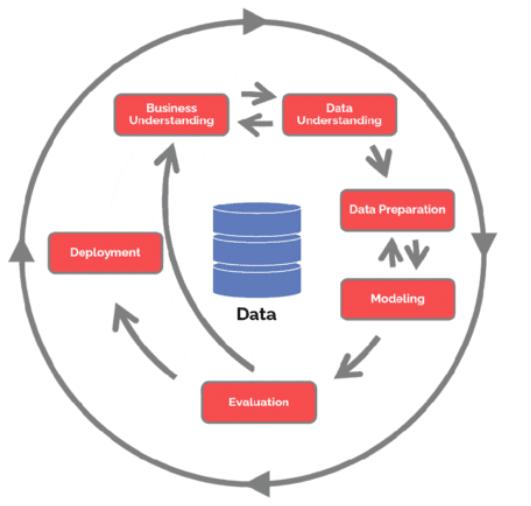



# **STEP 1: Problem/Business understanding -->> Define Data problem**

Data understanding --->>Researchers and healthcare providers use workplace conditions and socioeconomic data as powerful, non-clinical predictors to assess the risk of mental health conditions

# **STEP 2: Data understanding**

## Sub-Steps to follow

* **Explore Data:** Conduct Exploratory Data Analysis (EDA) to dive deeper. This involves calculating basic statistics, visualizing distributions, and identifying relationships between variables.
* **Load Initial Data:** Observe the necessary datasets from by Kaggel .
* **Describe Data:** Examine the data properties: data formats, number of records, field identities (e.g., column names), and data types (numeric, nominal).
* **Target Class - Balanced? :** Class-Imbalance analysis
* **PCA:** To get more insights to major contributing factors affecting mental illness Risks
* **Feature Engineering:** For this usecase I will derived features which are related and /or are socioeconomically correlated.
* **Data Skewness:** Check data skeweness and take appropriate actions

* **Verify Data Quality:** Assess the data for issues like missing values, errors, inconsistencies, or duplicates. This will help in next data preparation step

# **STEP 3: EDA (Exploratory Data Analysys) & Feature Engineering**

In [1]:
import time
import warnings
# from pathlib import Path

!pip install category_encoders
!pip install xgboost
import nbformat
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import  RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split,RandomizedSearchCV

from category_encoders import BinaryEncoder,OrdinalEncoder
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,  StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.9 MB/s eta 0:00:00


# Data Analysis ####

### Display first 5 rows, feature data types & descriptive statistics

In [ ]:
mental_health = pd.read_csv("../data/mental_health_risk_dataset.csv")
mental_health.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.60,2.80,9.60,7,10,3,7,8,40,5,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.50,2.70,3.00,10,6,9,1,10,31,3,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.10,14.10,7.20,10,5,2,4,7,28,8,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.00,0.50,10.30,2,10,4,8,7,63,9,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.10,2.50,1.20,8,1,8,8,3,28,1,8,3,3,1,0,0,1,0,1,0


In [3]:
mental_health.info()
mental_health.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

,count,mean,std,min,25%,50%,75%,max
age,"25,000.00",39.07,12.40,18.00,28.00,39.00,50.00,60.00
sleep_hours,"25,000.00",6.51,2.02,3.00,4.80,6.50,8.20,10.00
physical_activity_hours_per_week,"25,000.00",7.52,4.32,0.00,3.80,7.50,11.30,15.00
screen_time_hours_per_day,"25,000.00",6.47,3.17,1.00,3.70,6.50,9.20,12.00
social_support_score,"25,000.00",5.51,2.89,1.00,3.00,5.00,8.00,10.00
work_stress_level,"25,000.00",5.52,2.86,1.00,3.00,6.00,8.00,10.00
academic_pressure_level,"25,000.00",5.45,2.86,1.00,3.00,5.00,8.00,10.00
job_satisfaction_score,"25,000.00",5.47,2.87,1.00,3.00,5.00,8.00,10.00
financial_stress_level,"25,000.00",5.50,2.88,1.00,3.00,5.00,8.00,10.00
working_hours_per_week,"25,000.00",45.05,14.68,20.00,32.00,45.00,58.00,70.00


# Explore relationship of all features with mental_health_risk(target variable) in original dataset

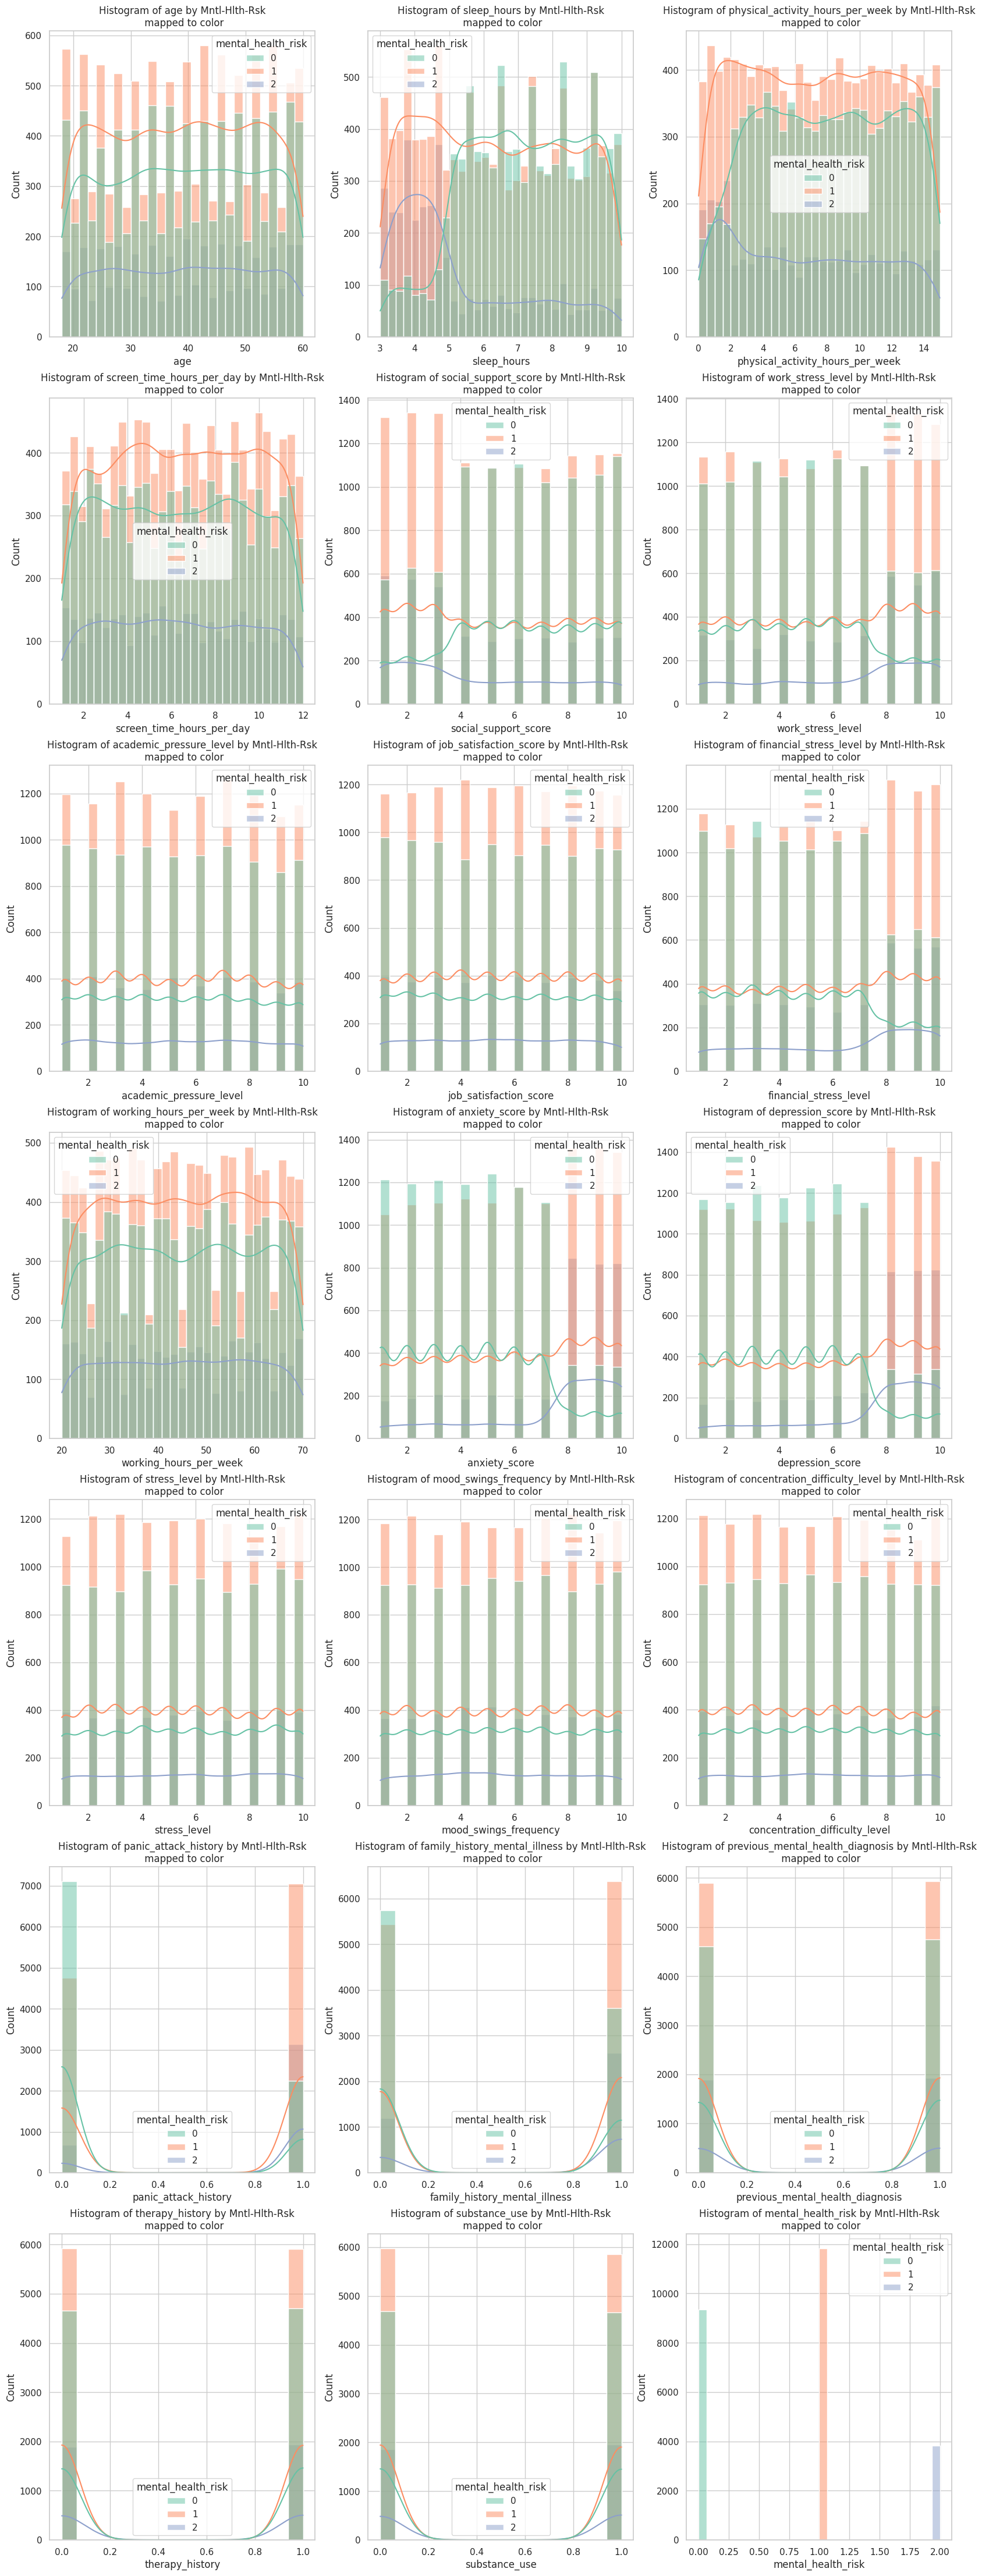

In [4]:
import math

# Get numeric columns
numeric_cols = mental_health.select_dtypes(include=np.number).columns
n_cols = len(numeric_cols)

# Calculate rows needed for a 3-column wide grid
n_rows = math.ceil(n_cols / 3)

plt.figure(figsize=(20, 8 * n_rows))

for i, column in enumerate(numeric_cols):
    plt.subplot(n_rows, 3, i + 1)  # Dynamic row count
    #px.box(mental_health, x=column, y="mental_health_risk", color="mental_health_risk",
           #title=f'Boxplot of {column}', labels={column: column, "mental_health_risk": "Mental Health Risk"},
           #color_discrete_sequence=px.colors.qualitative.Set2).show()
    '''sns.boxplot(x=mental_health[column], y=mental_health["mental_health_risk"] #, palette="Set2"
                 ,flierprops={"marker": "x"}, # Change outlier shape
             fliersize=5)
    plt.title(f'Boxplot of {column}')'''
    sns.histplot(data=mental_health, x=column, hue="mental_health_risk", kde=True, palette="Set2")
    plt.title(f'Histogram of {column} by Mntl-Hlth-Rsk\n mapped to color')
    plt.xlabel(column)
    plt.ylabel("Count")

# plt.tight_layout()
plt.show()


# **STEP 3: Data Preparation & continue EDA further with new feature engineered data**

## FEATURE ENGINEERING & CREATE DERIVED COLUMNS

# Derived column definition

<table style="border-collapse: collapse; border: 1px solid black; width: 100%;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid black; padding: 8px;">SourceColumn</th>
      <th style="border: 1px solid black; padding: 8px;">DerivedColumn</th>
    </tr>
  </thead>
<tbody>
  <tr>
    <td style="border: 1px solid black; padding: 8px;"> anxiety_score |  depression_score | stress_level </td>
    <td style="border: 1px solid black; padding: 8px;">total_distress_score</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">work_stress_level | academic_pressure_level | financial_stress_level</td>
    <td style="border: 1px solid black; padding: 8px;">situational_stress_load</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">working_hours_per_week | sleep_hours</td>
    <td style= "border: 1px solid black; padding: 8px;">work_to_sleep_ratio</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">physical_activity_hours_per_week | screen_time_hours_per_day</td>
    <td style= "border: 1px solid black; padding: 8px;">work_to_sleep_ratio</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">panic_attack_history | family_history_mental_illness | previous_mental_health_diagnosis | substance_use | therapy_history</td>
    <td style= "border: 1px solid black; padding: 8px;">clinical_vulnerability_index</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">social_support_score | job_satisfaction_score | work_stress_level</td>
    <td style= "border: 1px solid black; padding: 8px;">protective_buffer_score</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">age</td>
    <td style= "border: 1px solid black; padding: 8px;">age_group</td>
  </tr>
 </tbody>

</table>


In [ ]:
# Make a copy to apply feature engineering without modifying the original sample_data
new_data_engineered_df = mental_health.copy()

# ==========================================
# 1. COMPOSITE CLINICAL & PSYCHOLOGICAL SCORES
# ==========================================
new_data_engineered_df['total_distress_score'] = new_data_engineered_df['anxiety_score'] + new_data_engineered_df['depression_score'] + new_data_engineered_df['stress_level']
new_data_engineered_df['situational_stress_load'] = new_data_engineered_df['work_stress_level'] + new_data_engineered_df['academic_pressure_level'] + new_data_engineered_df['financial_stress_level']


# ==========================================
# 2. LIFESTYLE BALANCE & INTERACTION METRICS
# ==========================================
new_data_engineered_df['work_to_sleep_ratio'] = new_data_engineered_df['working_hours_per_week'] / (new_data_engineered_df['sleep_hours'] * 7 + 1)
new_data_engineered_df['active_vs_screen_ratio'] = (new_data_engineered_df['physical_activity_hours_per_week'] / 7) / (new_data_engineered_df['screen_time_hours_per_day'] + 1)

# ==========================================
# 3. CLINICAL BACKGROUND & VULNERABILITY INDEX
# ==========================================
history_cols_new = ['panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'substance_use','therapy_history']
new_data_engineered_df['clinical_vulnerability_index'] = new_data_engineered_df[history_cols_new].sum(axis=1)
new_data_engineered_df['protective_buffer_score'] = (new_data_engineered_df['social_support_score'] + new_data_engineered_df['job_satisfaction_score']) - new_data_engineered_df['work_stress_level']

# ==========================================
# 4. CATEGORICAL ENCODING & DEMOGRAPHICS
# ==========================================
new_data_engineered_df['age_group'] = pd.cut(new_data_engineered_df['age'],
                         bins=[0, 24, 34, 50, 100],
                         labels=['Youth', 'Young_Adult', 'Adult', 'Senior'])


# ==========================================
# 5. TARGET COLUMN CATEGORICAL LABEL
# ==========================================
# Define bins and labels
bins = [-1,0,1, 2]
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Apply mapping to my dataframe column
new_data_engineered_df['risk_level'] = pd.cut(new_data_engineered_df['mental_health_risk'], bins=bins, labels=labels)

# Identify all numeric columns after feature engineering
# This will include original numeric columns and newly created numeric columns
numeric_cols_for_prediction = new_data_engineered_df.select_dtypes(include=[np.number]).columns.tolist()


# New derived numeric features
new_numeric_derived_features = ['total_distress_score', 'situational_stress_load', 'work_to_sleep_ratio',
                                'active_vs_screen_ratio', 'clinical_vulnerability_index', 'protective_buffer_score',
                                'age_group']
other_features_from_original_dataset = ['gender','marital_status','education_level','employment_status','mood_swings_frequency'
                                  ,'concentration_difficulty_level','mental_health_risk','risk_level']
# Combine all numeric features for the model input
all_features_for_model = other_features_from_original_dataset + new_numeric_derived_features


print("Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):")
display(new_data_engineered_df[all_features_for_model].head())
new_data_engineered_df[all_features_for_model].shape


Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):


,gender,marital_status,education_level,employment_status,mood_swings_frequency,concentration_difficulty_level,mental_health_risk,risk_level,total_distress_score,situational_stress_load,work_to_sleep_ratio,active_vs_screen_ratio,clinical_vulnerability_index,protective_buffer_score,age_group
0,Other,Single,Bachelor,Unemployed,8,3,1,Medium Risk,17,21,0.65,0.04,4,4,Senior
1,Male,Single,Bachelor,Unemployed,9,3,0,Low Risk,14,25,0.95,0.10,0,5,Adult
2,Female,Divorced,Bachelor,Student,4,2,2,High Risk,12,14,1.23,0.25,5,9,Senior
3,Other,Married,Bachelor,Employed,2,5,2,High Risk,22,21,1.26,0.01,4,0,Senior
4,Male,Single,High School,Self-Employed,3,1,0,Low Risk,12,12,0.76,0.16,2,15,Senior


(25000, 15)

# CHECK IF NEW ENGINEERED DATASET HAS ANY NULL VALUES

In [6]:
new_data_engineered_df[all_features_for_model].isna().sum()

,0
gender,0
marital_status,0
education_level,0
employment_status,0
mood_swings_frequency,0
concentration_difficulty_level,0
mental_health_risk,0
risk_level,0
total_distress_score,0
situational_stress_load,0


# Result indicates no NULL values

In [7]:
# Create a final feature engineered dataframe
mental_health_engineered_final_df = new_data_engineered_df[all_features_for_model]
mental_health_engineered_final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   gender                          25000 non-null  object  
 1   marital_status                  25000 non-null  object  
 2   education_level                 25000 non-null  object  
 3   employment_status               25000 non-null  object  
 4   mood_swings_frequency           25000 non-null  int64   
 5   concentration_difficulty_level  25000 non-null  int64   
 6   mental_health_risk              25000 non-null  int64   
 7   risk_level                      25000 non-null  category
 8   total_distress_score            25000 non-null  int64   
 9   situational_stress_load         25000 non-null  int64   
 10  work_to_sleep_ratio             25000 non-null  float64 
 11  active_vs_screen_ratio          25000 non-null  float64 
 12  clinical_vulnerabi

# Identify numeric & categorical coulmns in new feature engineered dataset

In [8]:
# Identify numeric & categorical columns

categorical_cols = mental_health_engineered_final_df.select_dtypes(include=["object","category"]).columns
numeric_cols = mental_health_engineered_final_df.select_dtypes(include=[np.number]).columns
# risk_level is created to use in plots &  not required for modelling
categorical_cols = [col for col in categorical_cols if col != 'risk_level']
print("\nCategorical columns:")
print(categorical_cols)
print("\nNumeric columns:")
print(numeric_cols)


Categorical columns:
['gender', 'marital_status', 'education_level', 'employment_status', 'age_group']

Numeric columns:
Index(['mood_swings_frequency', 'concentration_difficulty_level',
       'mental_health_risk', 'total_distress_score', 'situational_stress_load',
       'work_to_sleep_ratio', 'active_vs_screen_ratio',
       'clinical_vulnerability_index', 'protective_buffer_score'],
      dtype='object')


# CHECK DATA SKEWNESS

In [9]:
# find any data skewness

"""
    Calculate skewness for all numeric columns

    Interpretation:
    - Skewness = 0: Perfectly symmetric (normal distribution)
    - -0.5 to 0.5: Fairly symmetric
    - 0.5 to 1 or -1 to -0.5: Moderately skewed
    - > 1 or < -1: Highly skewed
    """
# BELOW INDICATES INPUT FEATURES  LOOKS SKEWED

skewness = mental_health_engineered_final_df[numeric_cols].skew()
print("Skewness of numeric features:")
print(skewness)

Skewness of numeric features:
mood_swings_frequency            -0.00
concentration_difficulty_level    0.01
mental_health_risk                0.32
total_distress_score              0.01
situational_stress_load           0.01
work_to_sleep_ratio               1.04
active_vs_screen_ratio            1.80
clinical_vulnerability_index     -0.02
protective_buffer_score           0.02
dtype: float64


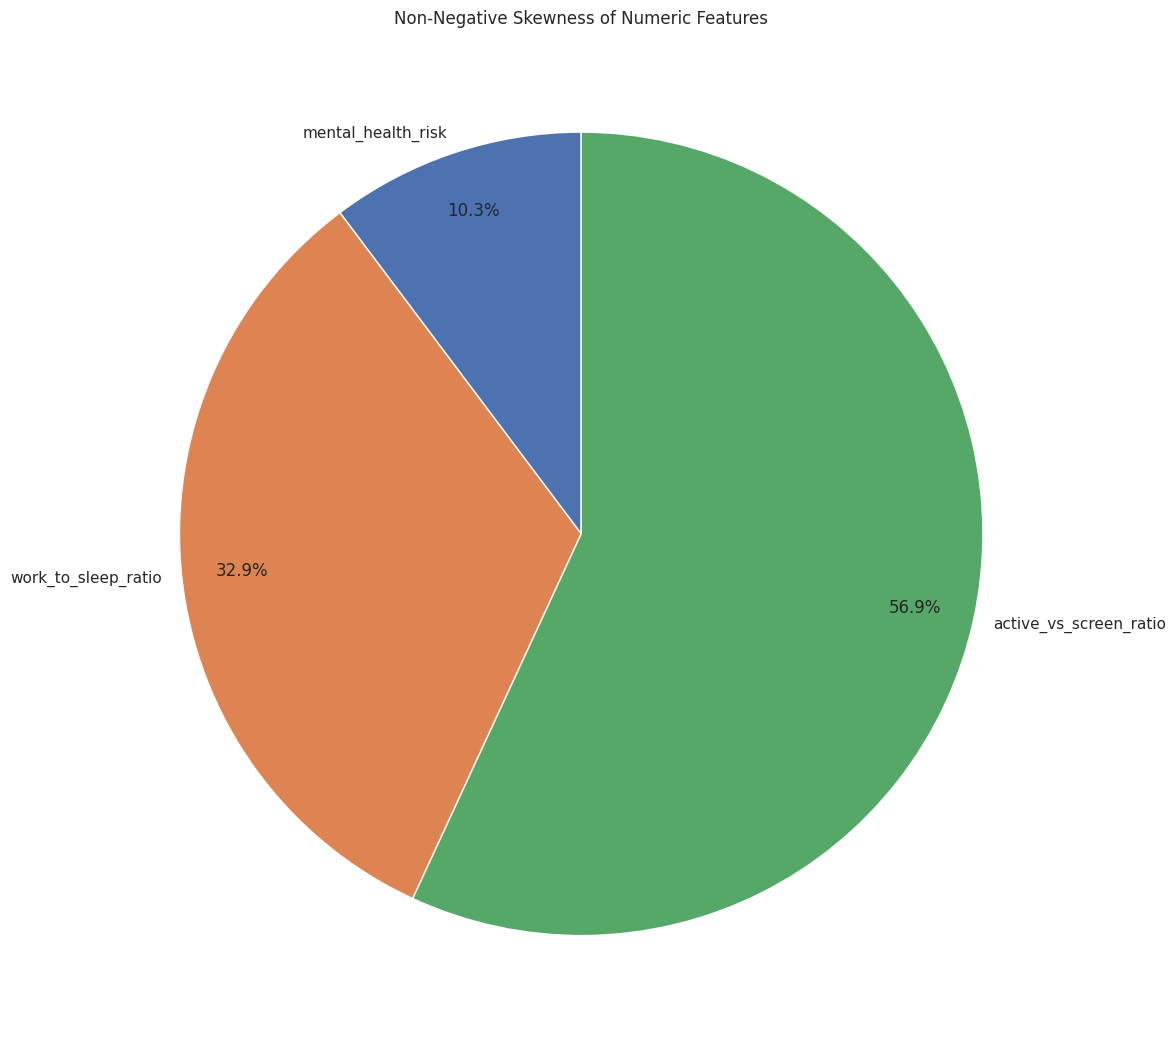

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out negative skewness values for pie chart
plot_skewness = mental_health_engineered_final_df[numeric_cols].skew()
positive_skewness = plot_skewness[plot_skewness > 0.02]

plt.figure(figsize=(12, 12)) # Increased figure size
plt.pie(positive_skewness,
        labels=positive_skewness.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85, # Distance of percentage labels from center
        labeldistance=1.05) # Distance of text labels from center
plt.title('Non-Negative Skewness of Numeric Features')
plt.tight_layout()
plt.show()

In [11]:
# Get categorical columns vs numeric columns for later use in preprocessing

unique_vals = {col: mental_health_engineered_final_df[col].unique() for col in categorical_cols}

print('DISPLAY UNIQUE VALUES FOR EACH CATEGORICAL FEATURE ')
for key, value in unique_vals.items():
    print(f"{key}: {value}")



DISPLAY UNIQUE VALUES FOR EACH CATEGORICAL FEATURE 
gender: ['Other' 'Male' 'Female']
marital_status: ['Single' 'Divorced' 'Married']
education_level: ['Bachelor' 'High School' 'Master' 'PhD']
employment_status: ['Unemployed' 'Student' 'Employed' 'Self-Employed']
age_group: ['Senior', 'Adult', 'Youth', 'Young_Adult']
Categories (4, object): ['Youth' < 'Young_Adult' < 'Adult' < 'Senior']


# Class-Imbalance analysis

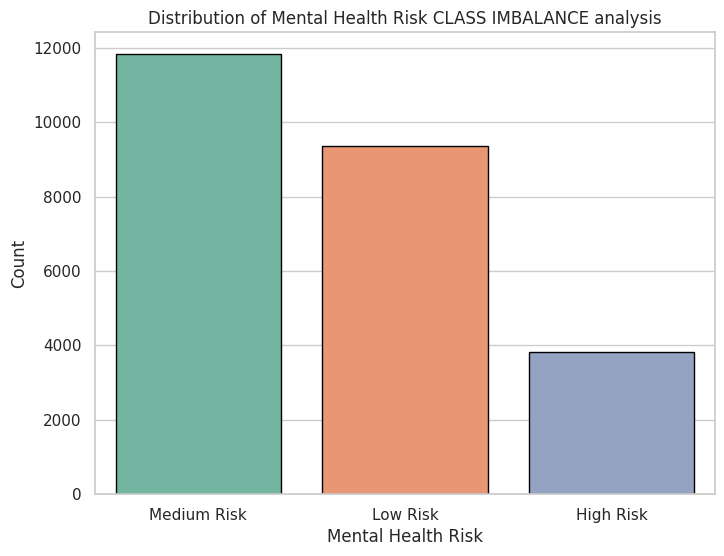

In [12]:
# Class Imbalance Evaluation. Target distribution pattern is important to understand for model selection and evaluation.
# map the target variable to more descriptive labels for better visualization
mental_health_for_plt = mental_health_engineered_final_df.copy()
mental_health_for_plt["mental_health_risk"] = mental_health_engineered_final_df["mental_health_risk"].map({0: "Low Risk", 1: "Medium Risk", 2: "High Risk"})

plt.figure(figsize=(8, 6))
sns.countplot(data=mental_health_for_plt, x="mental_health_risk", palette="Set2", edgecolor="black",)
plt.title("Distribution of Mental Health Risk CLASS IMBALANCE analysis")
plt.xlabel("Mental Health Risk")
plt.ylabel("Count")
plt.show()

#### USE OrdinalEncoder for categorical features
***Didn't use preprocessor OneHotEncoder or BinaryEncoder to keep the dimentionality unchanged/under control for PCA and HEAT MAP. This will give better readability***

***So using category_encoders' OrdinalEncoder for all categorical features***

In [13]:
encoder = OrdinalEncoder()  # using this from category_encoders instead of sklearn's OrdinalEncoder to handle unknown categories gracefully during transformation
df_encoded = mental_health_engineered_final_df.copy()
df_encoded[categorical_cols] = encoder.fit_transform(df_encoded[categorical_cols])
print("\nDataFrame after ordinal encoding:")
display(df_encoded.head())
display(df_encoded.isna().sum())
display(df_encoded.describe().T)


DataFrame after ordinal encoding:


,gender,marital_status,education_level,employment_status,mood_swings_frequency,concentration_difficulty_level,mental_health_risk,risk_level,total_distress_score,situational_stress_load,work_to_sleep_ratio,active_vs_screen_ratio,clinical_vulnerability_index,protective_buffer_score,age_group
0,1,1,1,1,8,3,1,Medium Risk,17,21,0.65,0.04,4,4,4
1,2,1,1,1,9,3,0,Low Risk,14,25,0.95,0.10,0,5,3
2,3,2,1,2,4,2,2,High Risk,12,14,1.23,0.25,5,9,4
3,1,3,1,3,2,5,2,High Risk,22,21,1.26,0.01,4,0,4
4,2,1,2,4,3,1,0,Low Risk,12,12,0.76,0.16,2,15,4


,0
gender,0
marital_status,0
education_level,0
employment_status,0
mood_swings_frequency,0
concentration_difficulty_level,0
mental_health_risk,0
risk_level,0
total_distress_score,0
situational_stress_load,0


,count,mean,std,min,25%,50%,75%,max
gender,"25,000.00",2.00,0.81,1.00,1.00,2.00,3.00,3.00
marital_status,"25,000.00",2.01,0.81,1.00,1.00,2.00,3.00,3.00
education_level,"25,000.00",2.49,1.12,1.00,1.00,2.00,3.00,4.00
employment_status,"25,000.00",2.50,1.12,1.00,2.00,3.00,3.00,4.00
mood_swings_frequency,"25,000.00",5.51,2.87,1.00,3.00,6.00,8.00,10.00
concentration_difficulty_level,"25,000.00",5.49,2.87,1.00,3.00,5.00,8.00,10.00
mental_health_risk,"25,000.00",0.78,0.69,0.00,0.00,1.00,1.00,2.00
total_distress_score,"25,000.00",16.57,4.99,3.00,13.00,17.00,20.00,30.00
situational_stress_load,"25,000.00",16.46,4.96,3.00,13.00,16.00,20.00,30.00
work_to_sleep_ratio,"25,000.00",1.08,0.52,0.28,0.68,0.97,1.34,3.18


# PCA analysis to find the most important features

#### DEFINE A FUNCTION FOR PCA ANALYSIS

In [ ]:
from sklearn.decomposition import PCA


def apply_pca_and_plot_variance(X_scaled, df, palette,type_text):

# Apply PCA
    pca = PCA(n_components=None) # Keep all components for now to examine variance
    pca.fit(X_scaled)

    # Explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_
    print(f"Explained variance ratio of each component - {type_text}:", explained_variance_ratio)

    # Cumulative explained variance
    cum_explained_variance = np.cumsum(explained_variance_ratio)
    print(f"Cumulative explained variance - {type_text}:", cum_explained_variance)

    # Plot explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance_ratio) + 1), cum_explained_variance, marker='o', linestyle='--')
    plt.title(f'Cumulative Explained Variance by PCA Components - {type_text}:')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()

    # To see which original features contribute to each principal component,
    # I can inspect the `components_` attribute of the PCA model.
    # Each row in `pca.components_` corresponds to a principal component,
    # and each column corresponds to an original feature in the order they were in X_scaled.
    print(f"\nPrincipal Components (loadings) - {type_text}:")
    pca_components_df = pd.DataFrame(pca.components_, columns=df.columns)
    print(pca_components_df.head())

    # For example, to see the features that contribute most to the first principal component:
    print(f"\nTop features contributing to the first principal component - {type_text}:")
    print(pca_components_df.iloc[0].sort_values(ascending=False))

    num_components_to_plot = 5 # I can adjust this number
    plt.figure(figsize=(15, 5 * num_components_to_plot))

    for i in range(num_components_to_plot):
        # Get the loadings for the current principal component
        component_loadings = pca_components_df.iloc[i]

        # Sort by absolute value to find the most influential features
        sorted_loadings = component_loadings.abs().sort_values(ascending=False)

        # Get the top N features (e.g., top 5) and their actual loadings
        top_features = sorted_loadings.head(5).index
        top_loadings = component_loadings[top_features]

        plt.subplot(num_components_to_plot, 1, i + 1)
        sns.barplot(x=top_loadings.index, y=top_loadings.values, palette=palette)
        plt.title(f'Top Feature Contributions to Principal Component {i + 1} - {type_text}:')
        plt.xlabel('Feature')
        plt.ylabel('Loading Value')
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

#### COMPARE BETWEEN NUMERIC ONLY VS NUMERIC & CATEGORICAL COMBINE FEATURE.

### DO THE CATEGORICAL FEATURES HAVE SIGNIFICANT IMPACT IN PCA ANALYSIS FOR THIS USE CASE?

Explained variance ratio of each component - Numeric & Categorical: [0.10228775 0.0798727  0.0790217  0.07829012 0.07758271 0.07716591
 0.07698238 0.07661433 0.07583598 0.07515687 0.07499613 0.07454804
 0.0516454 ]
Cumulative explained variance - Numeric & Categorical: [0.10228775 0.18216044 0.26118214 0.33947226 0.41705496 0.49422088
 0.57120325 0.64781758 0.72365356 0.79881043 0.87380656 0.9483546
 1.        ]


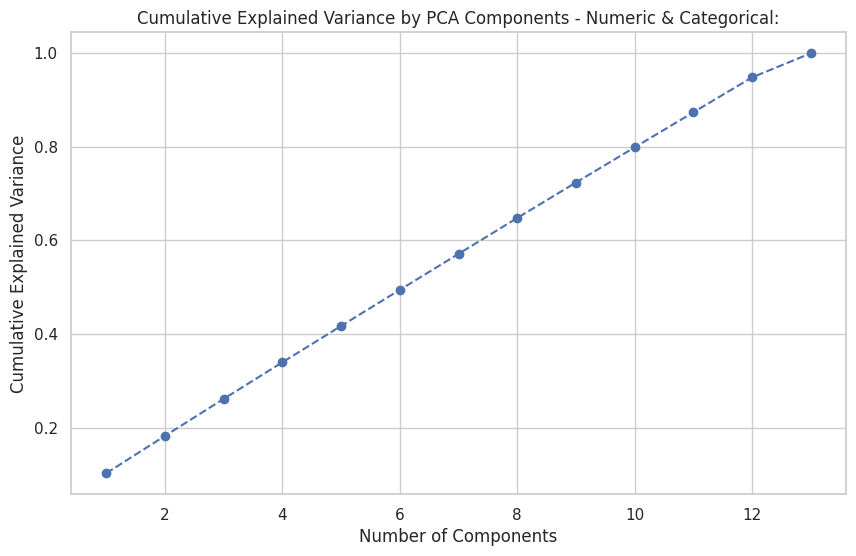


Principal Components (loadings) - Numeric & Categorical:
   gender  marital_status  education_level  employment_status  \
0   -0.02           -0.06             0.01               0.03   
1   -0.21           -0.33             0.41               0.02   
2    0.22           -0.41            -0.48              -0.15   
3    0.39           -0.29             0.06              -0.39   
4   -0.32           -0.40            -0.09               0.27   

   mood_swings_frequency  concentration_difficulty_level  \
0                   0.01                            0.02   
1                   0.02                            0.51   
2                   0.30                            0.13   
3                  -0.35                           -0.23   
4                   0.54                           -0.32   

   total_distress_score  situational_stress_load  work_to_sleep_ratio  \
0                 -0.00                     0.71                -0.03   
1                  0.12                    -

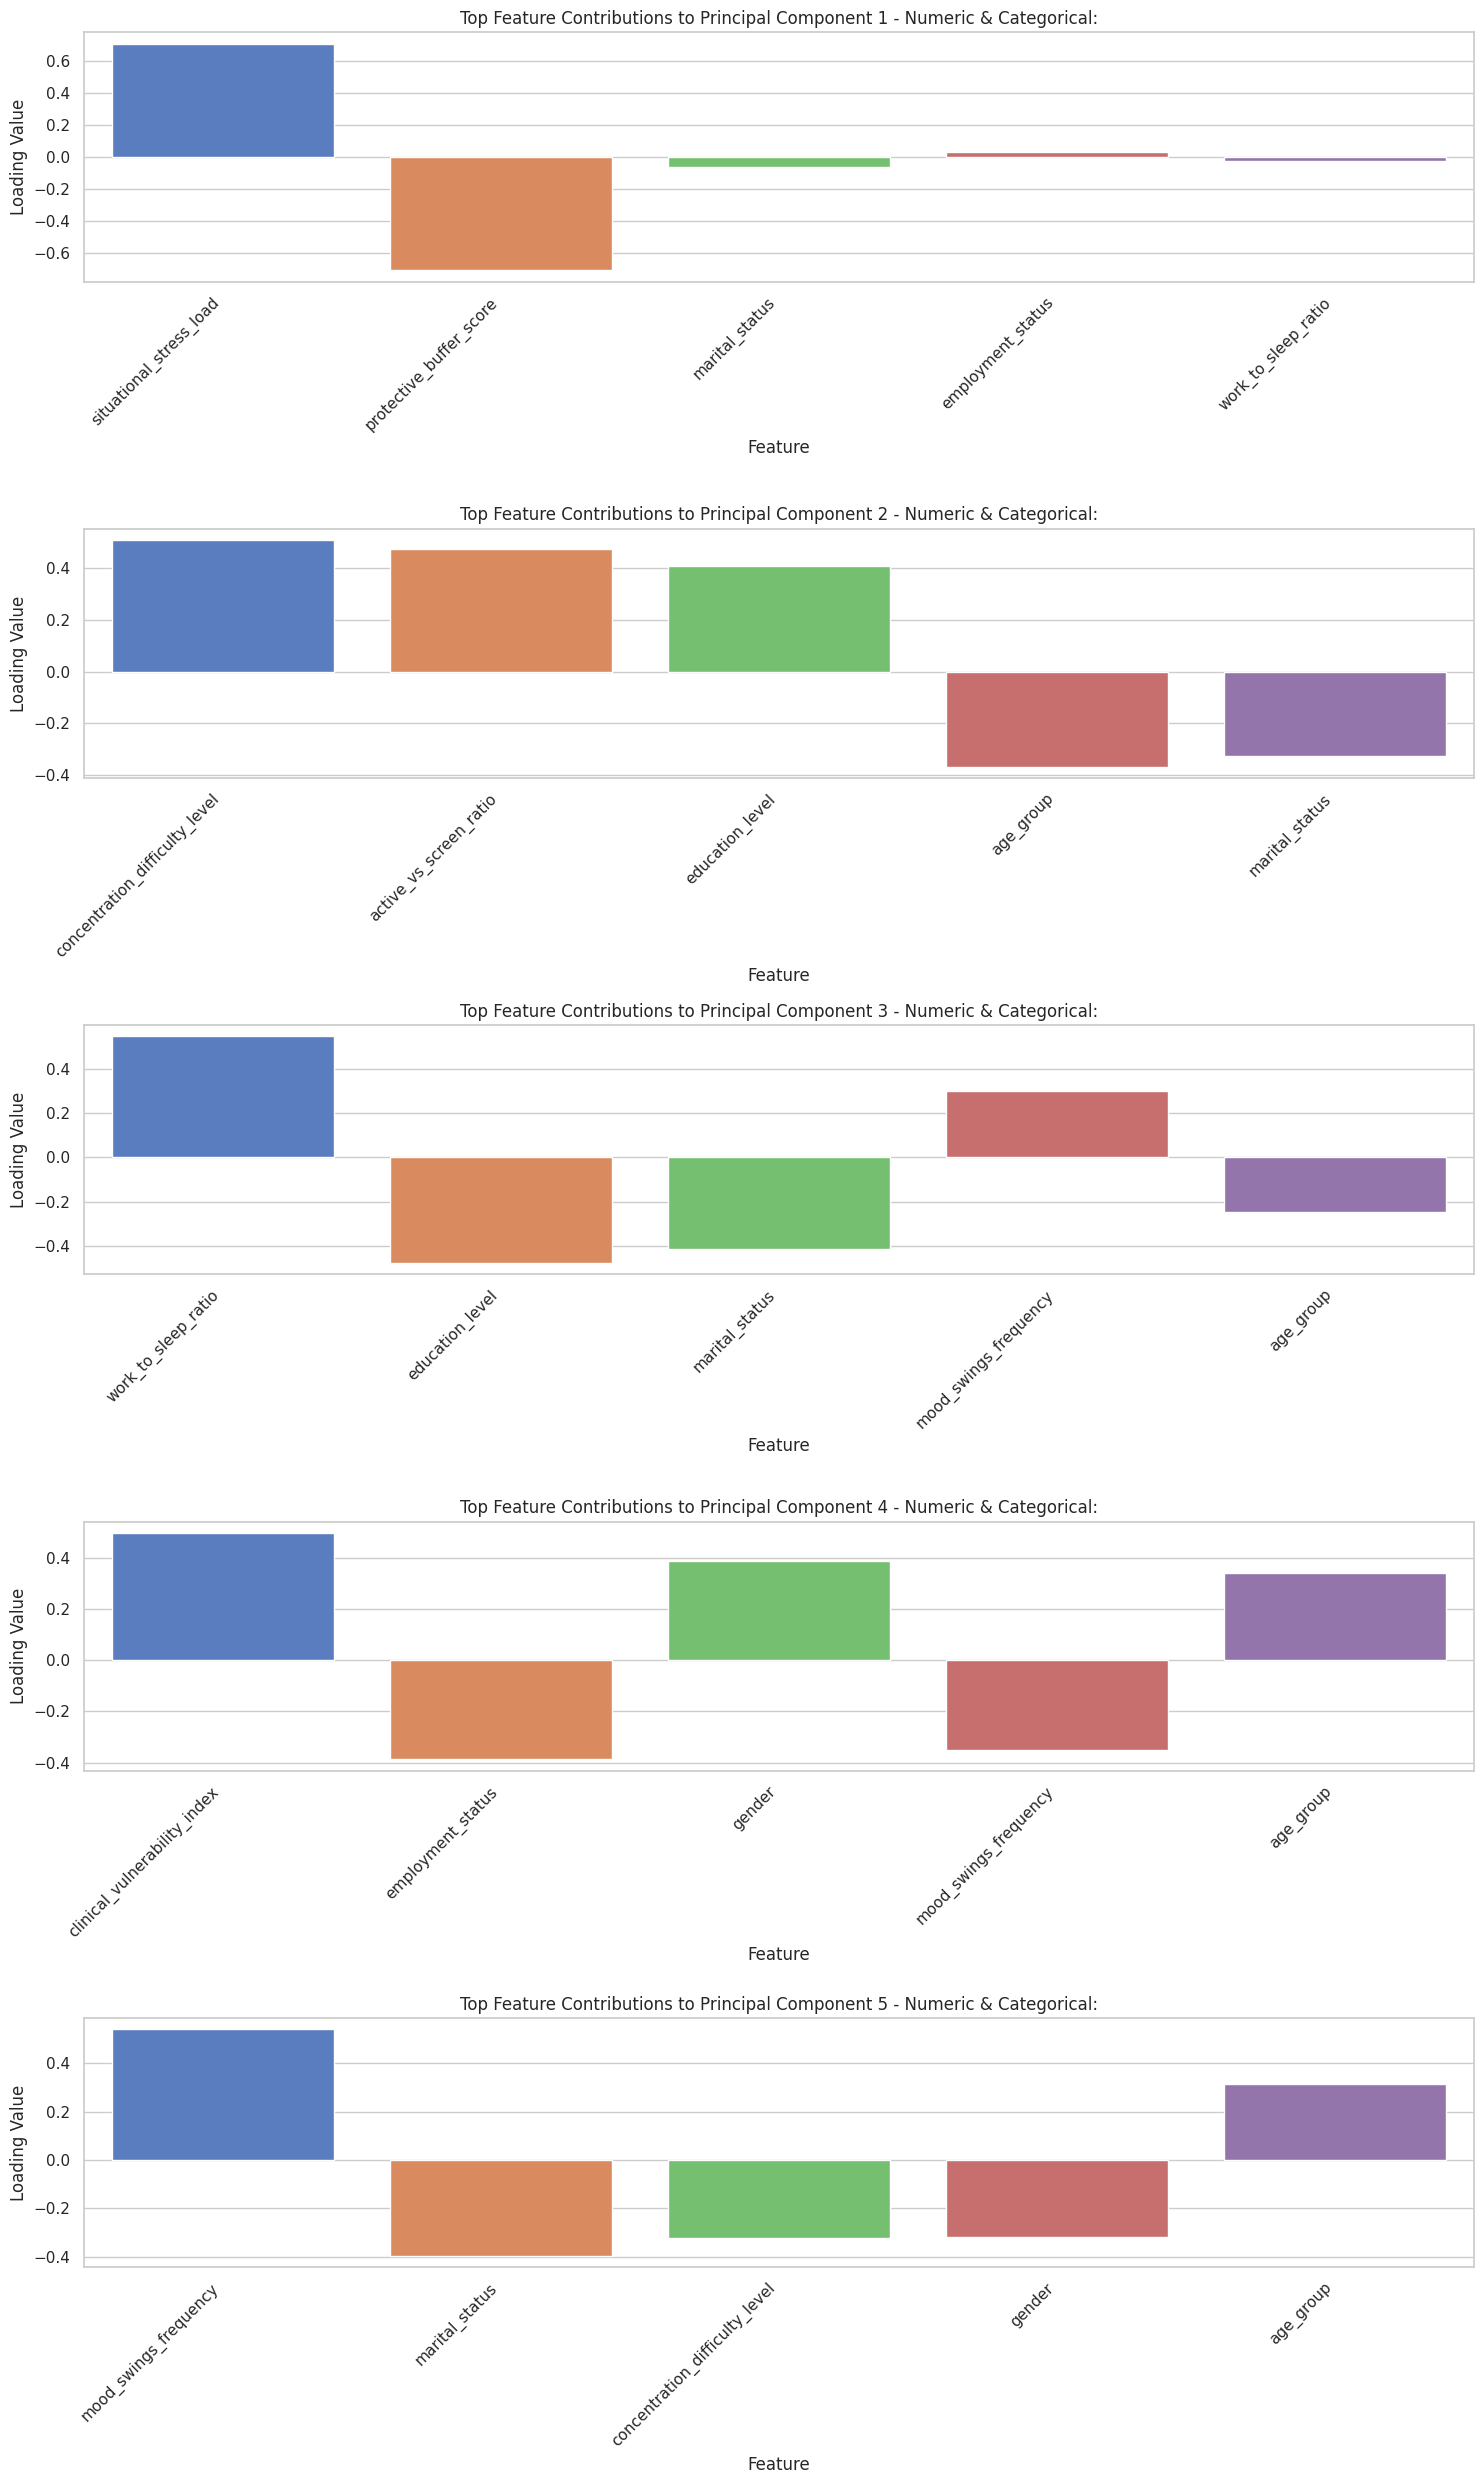

Explained variance ratio of each component - Numeric Only: [0.16600162 0.12656438 0.12623837 0.12498262 0.12482609 0.12411687
 0.12330865 0.08396139]
Cumulative explained variance - Numeric Only: [0.16600162 0.292566   0.41880437 0.54378699 0.66861309 0.79272996
 0.91603861 1.        ]


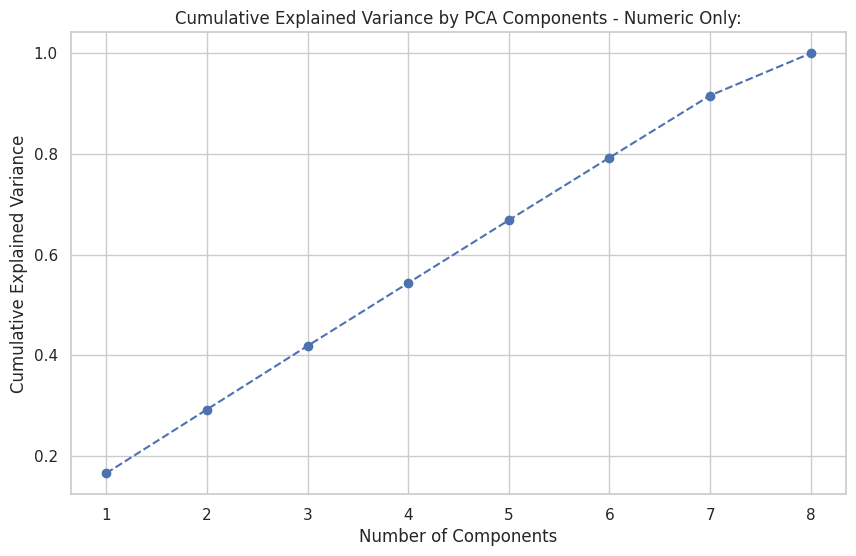


Principal Components (loadings) - Numeric Only:
   mood_swings_frequency  concentration_difficulty_level  \
0                   0.01                            0.02   
1                  -0.54                            0.20   
2                   0.35                            0.64   
3                  -0.35                           -0.04   
4                  -0.18                           -0.13   

   total_distress_score  situational_stress_load  work_to_sleep_ratio  \
0                 -0.00                     0.71                -0.03   
1                  0.35                    -0.01                -0.10   
2                  0.34                    -0.02                 0.26   
3                  0.31                     0.00                 0.77   
4                  0.66                    -0.00                -0.51   

   active_vs_screen_ratio  clinical_vulnerability_index  \
0                   -0.01                          0.01   
1                    0.47        

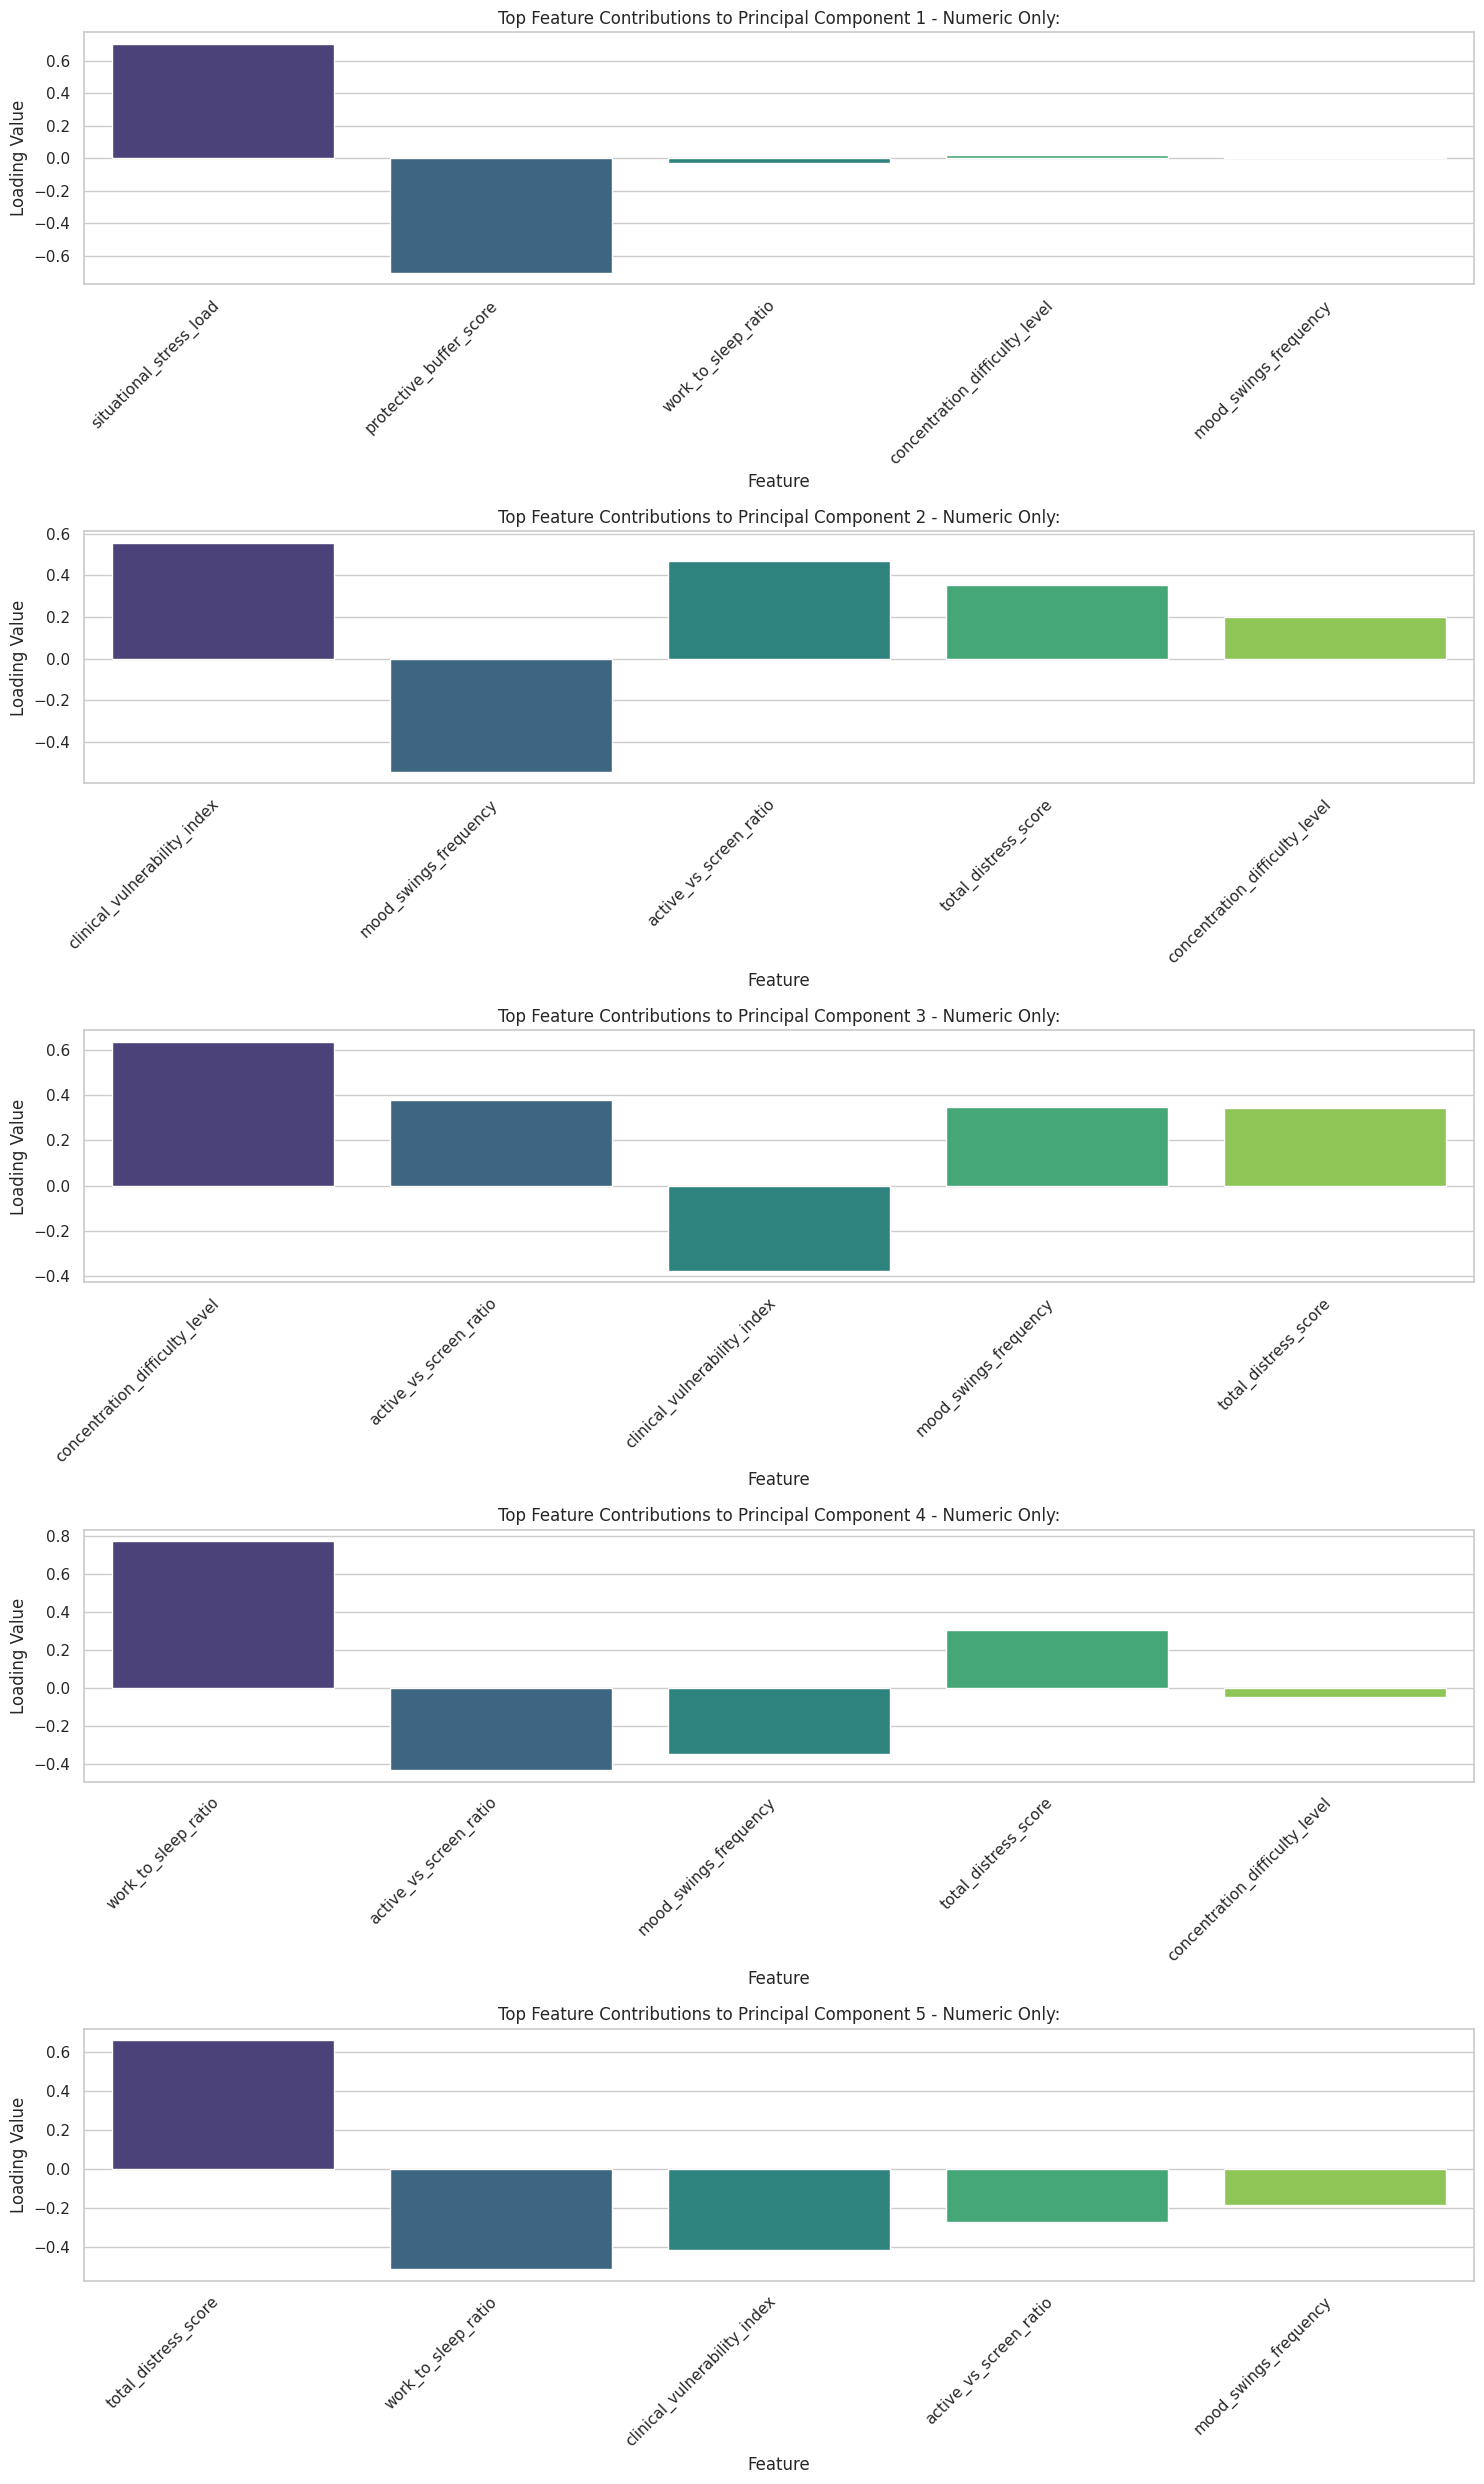

In [15]:
# df_encoded DF compositoin - categorical columns encoded with OrdinalEncoder + numeric columns

mental_health_pca = df_encoded.drop(columns=['mental_health_risk','risk_level'])
# mental_health_pca = pd.concat([mental_health_pca, mental_health_cat], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(mental_health_pca)
apply_pca_and_plot_variance(X_scaled, mental_health_pca,palette='muted',type_text='Numeric & Categorical')



mental_health_numeric_pca = mental_health_engineered_final_df[numeric_cols].drop(columns='mental_health_risk')
scaler_numeric = StandardScaler()
X_scaled_numeric = scaler_numeric.fit_transform(mental_health_numeric_pca)
apply_pca_and_plot_variance(X_scaled_numeric, mental_health_numeric_pca,palette='viridis',type_text='Numeric Only')


# PCA analysis shows 7- 8 different factors (numeric only) contribute 80-85% to mental illness. Considering categorical &  numeric together,  10-12 features contribute to mental illness

**The first principal component (PC1) is the direction in space along which the data points have the highest or most variance.**

**From the above plots other PCA components like PC2/PC3 shows different important features which have most noticible variances.**

# CHECK INDEPENDENT/DEPENDENT VARIABLE CORELATIONS- HEAT MAP ANALYSIS

### It allows me to instantly visualize which features have the strongest positive or negative relationships with my target, streamlining feature selection and model building.

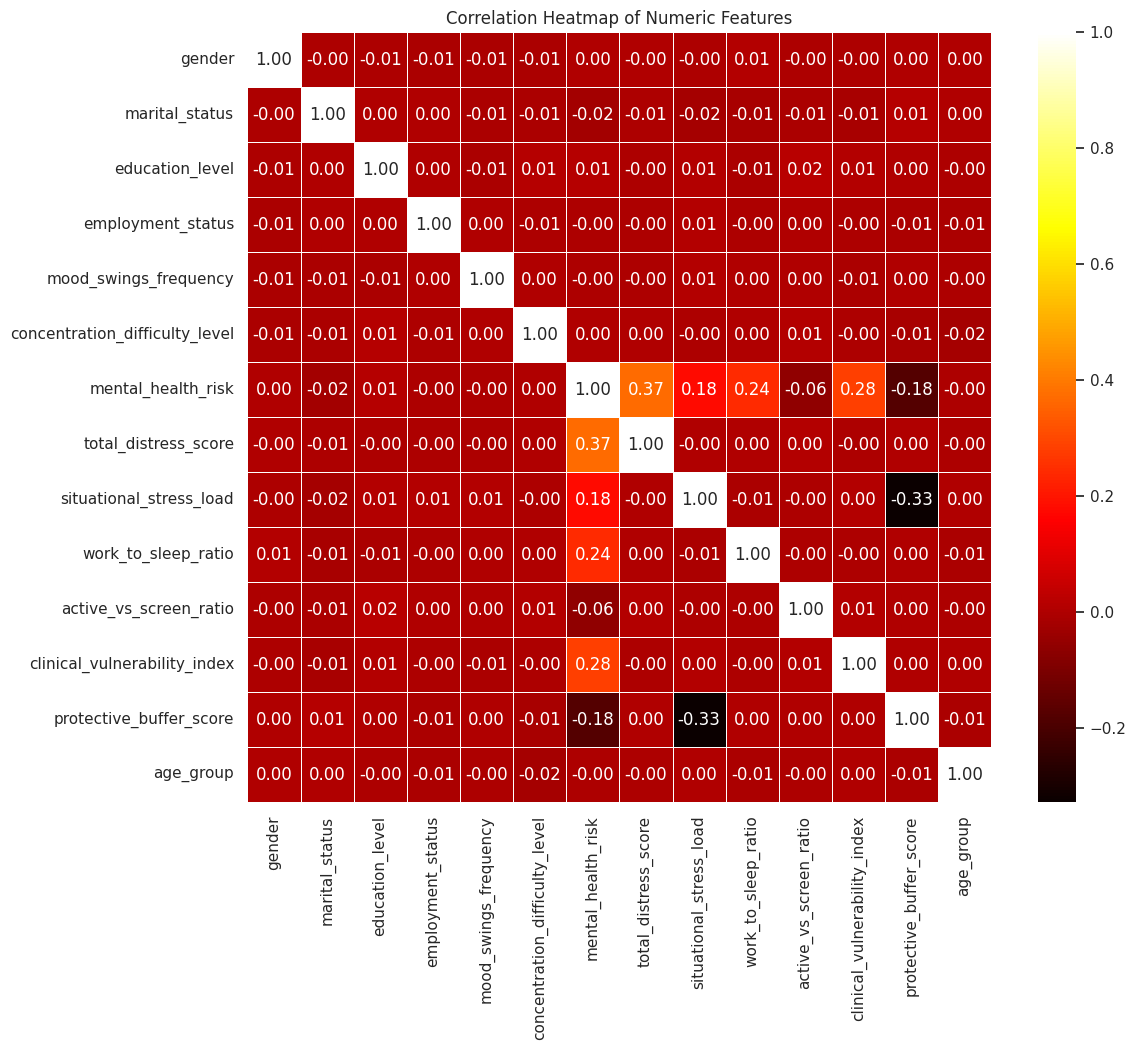

In [16]:
# PLOT CORRELATION HEATMAP. FOR CORRELATION/HEAT MAP ANALYSIS USE THE TARGET
# VARIABLE WHICH WAS NOT NEEDED FOR PCA ANALYSIS
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.drop(columns='risk_level').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='hot', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


#OUTCOME

***The results show --> It will be better to use both categorical and numeric features as indicated in PC2 and PC4 in PCA(Categorical & Numerical - combined) analysis above.***



# USE PAIRPLOT TO CHECK THE CORELATION AMONGST NUMERICAL FEATURES ####

***Spliting features into parts to enhance readability***

Features to split: ['gender', 'marital_status', 'education_level', 'employment_status', 'mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'work_to_sleep_ratio', 'active_vs_screen_ratio', 'clinical_vulnerability_index', 'protective_buffer_score', 'age_group']
Total numerical features (excluding target for splitting): 13

Features for pairplot part 1: ['gender' 'marital_status' 'education_level' 'employment_status']


<Figure size 2000x1800 with 0 Axes>

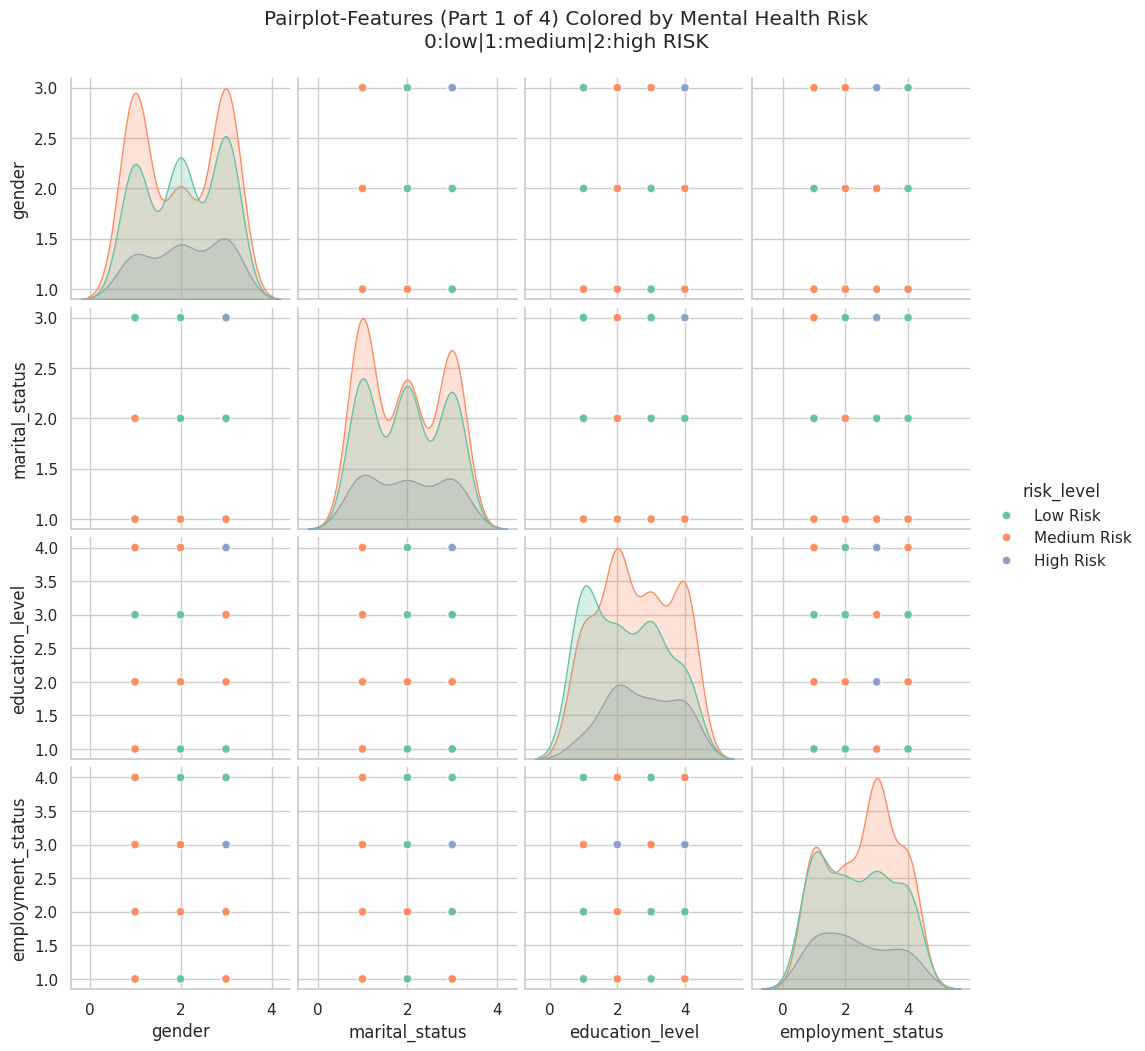


Features for pairplot part 2: ['mood_swings_frequency' 'concentration_difficulty_level'
 'total_distress_score']


<Figure size 2000x1800 with 0 Axes>

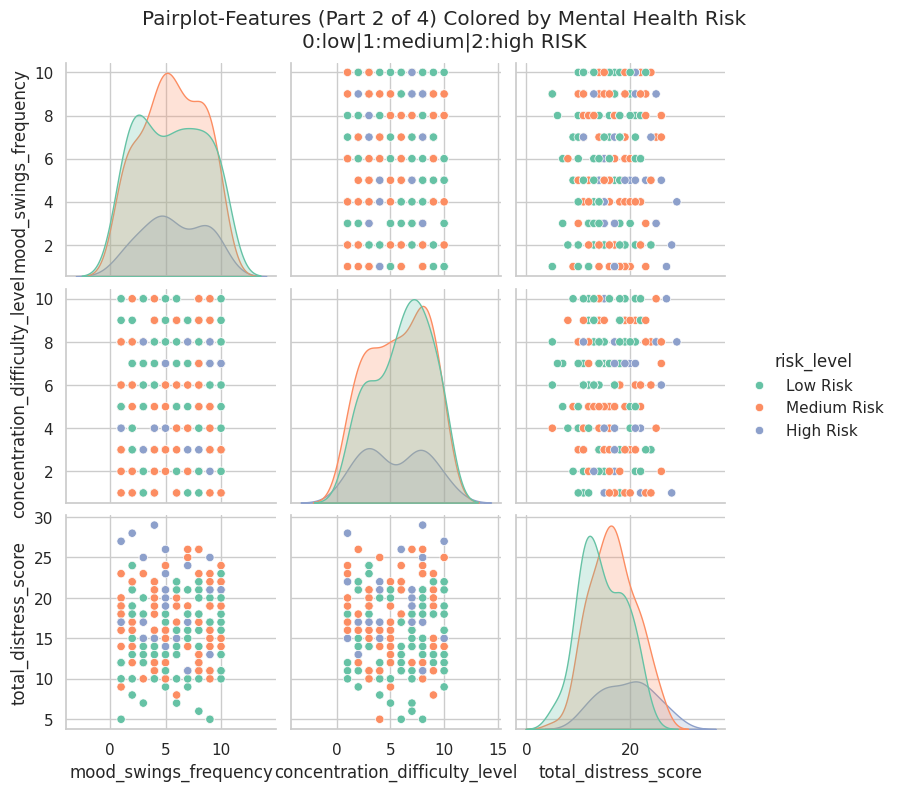


Features for pairplot part 3: ['situational_stress_load' 'work_to_sleep_ratio' 'active_vs_screen_ratio']


<Figure size 2000x1800 with 0 Axes>

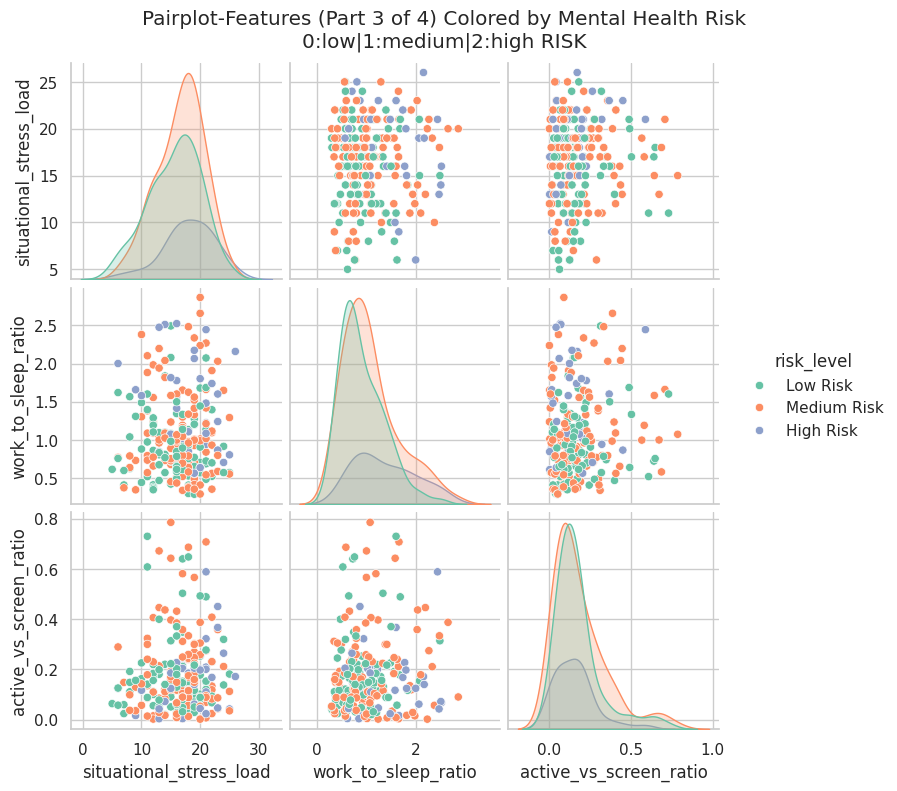


Features for pairplot part 4: ['clinical_vulnerability_index' 'protective_buffer_score' 'age_group']


<Figure size 2000x1800 with 0 Axes>

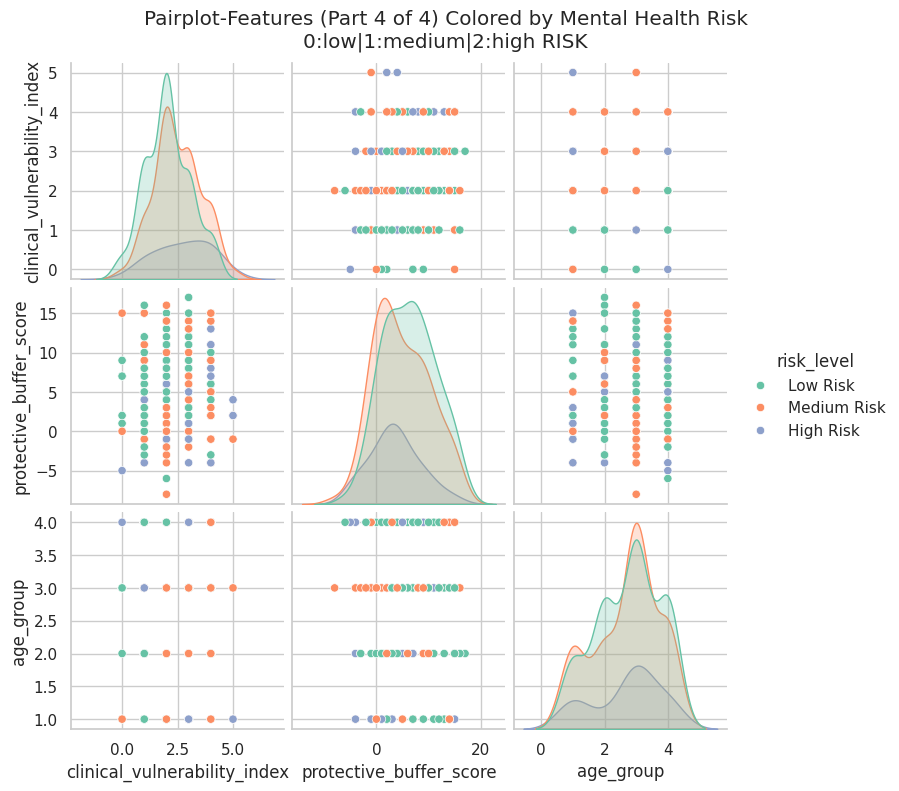

In [17]:

# df_encoded has encoded categorical + numeric columns
# Filter out the target for the feature splitting part
# (mental_health_risk will be added back for 'hue' in pairplot)
features_to_split = [col for col in df_encoded.columns if col not in ['mental_health_risk','risk_level']]
num_features = len(features_to_split)
print(f"Features to split: {features_to_split}")
print(f"Total numerical features (excluding target for splitting): {num_features}")

# Determine the number of parts (quarters)
num_parts = 4

# Split features into 4 parts
feature_parts = np.array_split(features_to_split, num_parts)

# Loop through each part and create a pairplot
for i, part_features in enumerate(feature_parts):
    # Add the 'mental_health_risk' column to the current set of features for hue
    cols_for_pairplot = list(part_features) + ['risk_level']

    print(f"\nFeatures for pairplot part {i+1}: {part_features}")

    # Create the pairplot for the current part
    plt.figure(figsize=(20, 18)) # Adjust figure size as needed
    ax = sns.pairplot(df_encoded[cols_for_pairplot].sample(frac=0.01), hue="risk_level", palette="Set2")
    plt.suptitle(f"Pairplot-Features (Part {i+1} of {num_parts}) Colored by Mental Health Risk\n0:low|1:medium|2:high RISK\n\n", y=1.05)
    plt.show()


# Factors affecting algorithm selection

***Linear Separability (Clear Boundaries):***

What to look for: In the scatter plots (off-diagonal plots), if the different classes (colored by mental_health_risk) can be neatly separated by a straight line (or hyper-plane in higher dimensions), then the data is said to be linearly separable.
Algorithm suitability: If I see clear linear boundaries, algorithms like Logistic Regression, Linear SVM (Support Vector Machine), or Perceptron could be highly effective. They are efficient and provide interpretable models.

***Non-linear Separability (Complex Boundaries):***

What to look for: If the classes are intertwined, form concentric circles, or have boundaries that are clearly curved or irregular, then a linear model won't capture these relationships well.
Algorithm suitability: Algorithms that can handle non-linear decision boundaries will be more suitable. This includes Decision Trees, Random Forests, Gradient Boosting Machines (like XGBoost, LightGBM), Kernel SVM (e.g., RBF kernel), K-Nearest Neighbors (KNN), and Neural Networks.

***Distribution Overlap:***

What to look for: Observe the histograms or density plots (diagonal plots) and the scatter plots. If the distributions of different classes highly overlap for many features, it suggests the classification problem is inherently difficult.
Algorithm suitability: For high overlap, algorithms that are good at finding subtle patterns or that can handle uncertainty, such as ensemble methods (Random Forest, Gradient Boosting), Neural Networks, or more sophisticated SVMs, might be necessary. Feature engineering to create more separating features would also be crucial.

***Clusterability:***

What to look for: Do the data points for each class tend to form distinct 'clouds' or clusters, even if they're not perfectly linearly separable?
Algorithm suitability: Algorithms like K-Nearest Neighbors (KNN), which makes predictions based on the majority class of its nearest neighbors, can work well here. If the clusters are very distinct, even simple models might perform adequately after proper scaling.

***Outliers and Noise:***

What to look for: Are there many data points far removed from their respective class clusters, or are there points that seem to belong to one class but are deep within another class's region?
Algorithm suitability: Algorithms robust to outliers, such as Random Forests or Gradient Boosting Machines, tend to be less affected than models like linear regression or some SVMs. Data preprocessing to handle outliers might also be needed.

***Feature Scaling and Importance:***

What to look for: Look at the ranges of features. Are some features on a much larger scale than others? Also, observe which features show the clearest separation between classes.
Algorithm suitability: Algorithms sensitive to feature scaling (SVMs, KNN, Logistic Regression, Neural Networks) will require StandardScaler or MinMaxScaler. Tree-based models are generally less sensitive to scaling but can still benefit. Features that show clear separation in the plots are likely important for classification.
By carefully examining these visual cues in my pair plots, I can form an initial hypothesis about the complexity of my classification problem and which family of algorithms might be a good starting point for my modeling efforts.



# **STEP 4:  MODELLING**

# Start with LogisticRegression/KNN/SVM/DecisionTree- Identify Base model

## Include both categorical & numeric features to evaluate the if categorical feature makes any difference

In [18]:
models = {
    "LogisticRegression": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200),
    # "rf": RandomForestClassifier(),
    "SupportVectorMachine": SVC(probability=True),
    "DecisionTree": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier()
}

metrics = {
        'Model': [],
        'Training Time': [],
        'Prediction Time': [],
        'Train Accuracy': [],
        'Test Accuracy': [],
        'Recall': [],
        'Confusion Matrix': [],
        'Classification Report': [],
        'ROC AUC': [],
        'F1': [],
        'Precision': []


        }

In [19]:
# numerical_cols_generic_evaluation = [col for col in numeric_cols if col != ['mental_health_risk','active_vs_screen_ratio','work_to_sleep_ratio']]
# print(numerical_cols_generic_evaluation)
log_transformation_cols = ['active_vs_screen_ratio', 'work_to_sleep_ratio']
print(log_transformation_cols)
numerical_cols_generic_evaluation = [col for col in numeric_cols if col not in ['mental_health_risk','risk_level'] + log_transformation_cols]
print(numerical_cols_generic_evaluation)

['active_vs_screen_ratio', 'work_to_sleep_ratio']
['mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'clinical_vulnerability_index', 'protective_buffer_score']


# NUMERIC - STANDARD SCALAR
# CATEGORICAL - OneHotEncoder
# SKEWED FEATURE - LOG TRANSFORMATION

In [20]:
from sklearn.preprocessing import FunctionTransformer
# ... (other imports)

column_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_generic_evaluation),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('log', FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one'), log_transformation_cols)
    ]
)

In [21]:
print(f'numeric columns ={numerical_cols_generic_evaluation}')
print(f'numeric log transformation columns ={log_transformation_cols}')
print(f'categorical columns={categorical_cols}')

numeric columns =['mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'clinical_vulnerability_index', 'protective_buffer_score']
numeric log transformation columns =['active_vs_screen_ratio', 'work_to_sleep_ratio']
categorical columns=['gender', 'marital_status', 'education_level', 'employment_status', 'age_group']


In [22]:
X = mental_health_engineered_final_df.drop(columns=['mental_health_risk','risk_level'])
y = mental_health_engineered_final_df['mental_health_risk']

### Split data into train & test set. Stratify during split to handle class imbalance in source data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

LogisticRegression Classification Report:               precision    recall  f1-score   support

    Low Risk       0.64      0.58      0.61      1871
 Medium Risk       0.57      0.71      0.63      2365
   High Risk       0.65      0.30      0.41       764

    accuracy                           0.60      5000
   macro avg       0.62      0.53      0.55      5000
weighted avg       0.61      0.60      0.59      5000



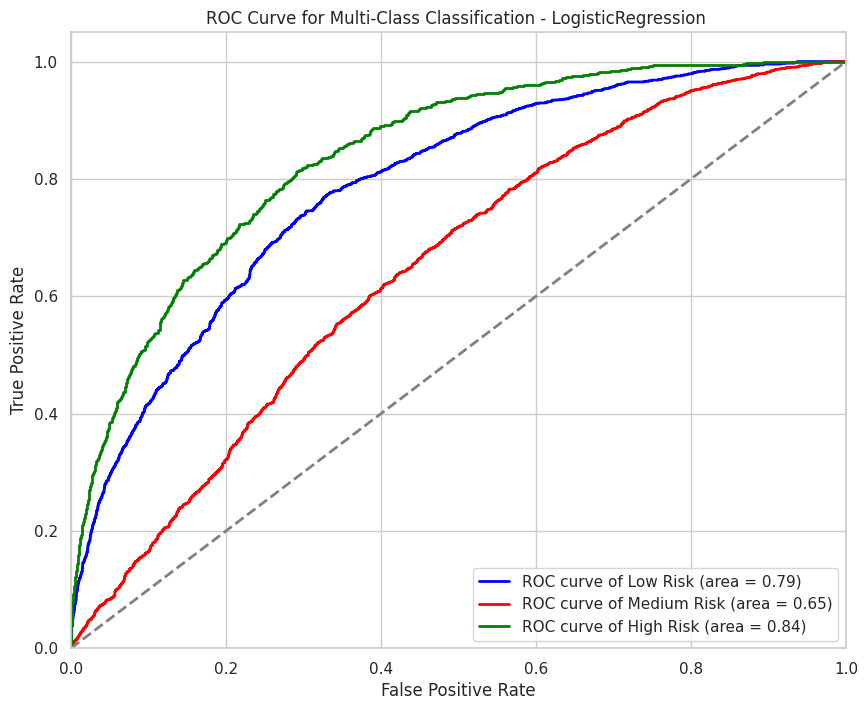

SupportVectorMachine Classification Report:               precision    recall  f1-score   support

    Low Risk       0.66      0.55      0.60      1871
 Medium Risk       0.56      0.77      0.64      2365
   High Risk       0.71      0.17      0.28       764

    accuracy                           0.59      5000
   macro avg       0.64      0.50      0.51      5000
weighted avg       0.62      0.59      0.57      5000



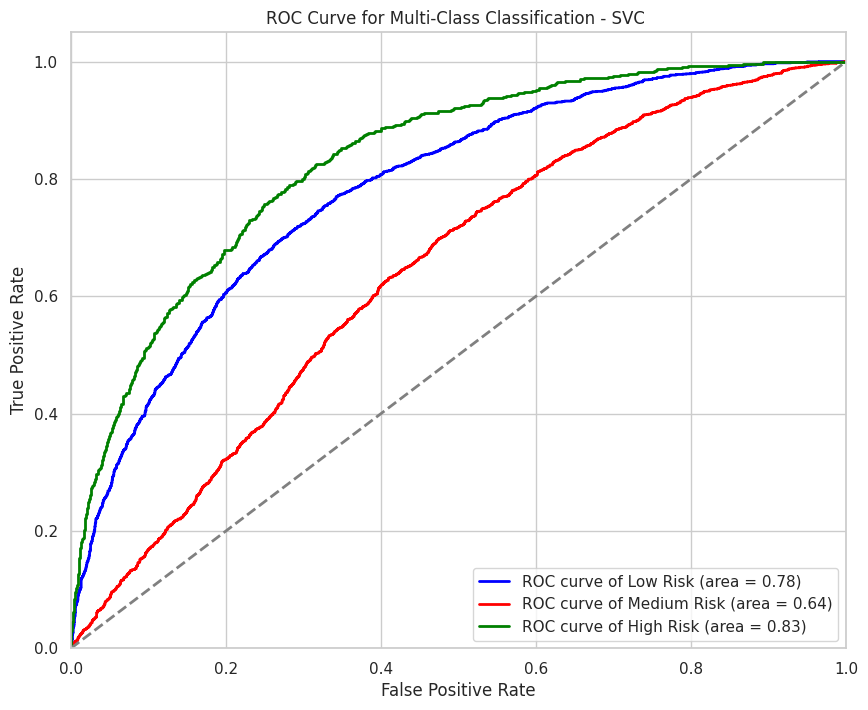

DecisionTree Classification Report:               precision    recall  f1-score   support

    Low Risk       0.65      0.46      0.54      1871
 Medium Risk       0.54      0.76      0.63      2365
   High Risk       0.58      0.25      0.35       764

    accuracy                           0.57      5000
   macro avg       0.59      0.49      0.51      5000
weighted avg       0.59      0.57      0.55      5000



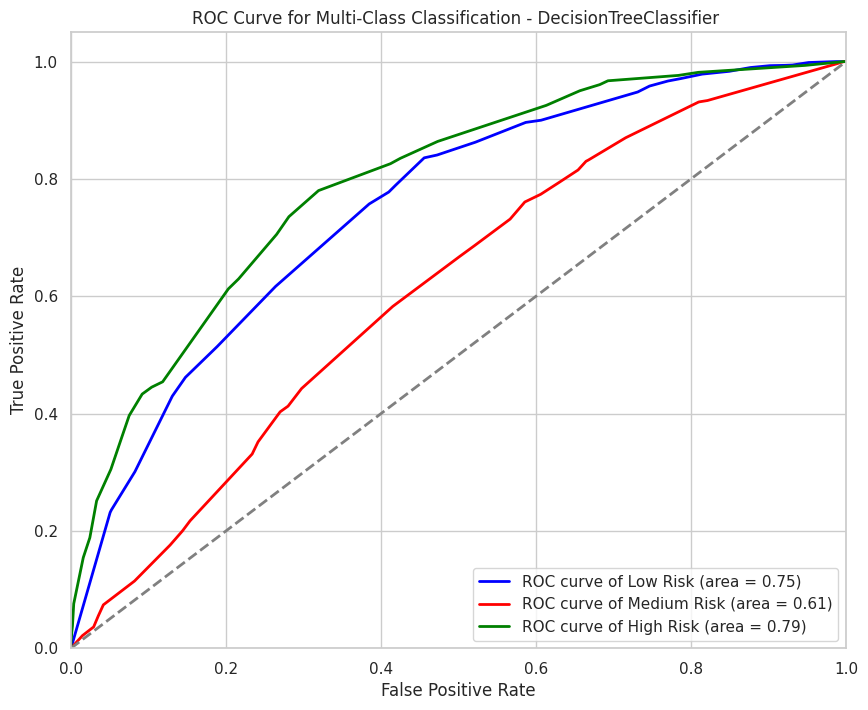

KNN Classification Report:               precision    recall  f1-score   support

    Low Risk       0.49      0.59      0.54      1871
 Medium Risk       0.51      0.55      0.53      2365
   High Risk       0.46      0.15      0.22       764

    accuracy                           0.50      5000
   macro avg       0.49      0.43      0.43      5000
weighted avg       0.50      0.50      0.48      5000



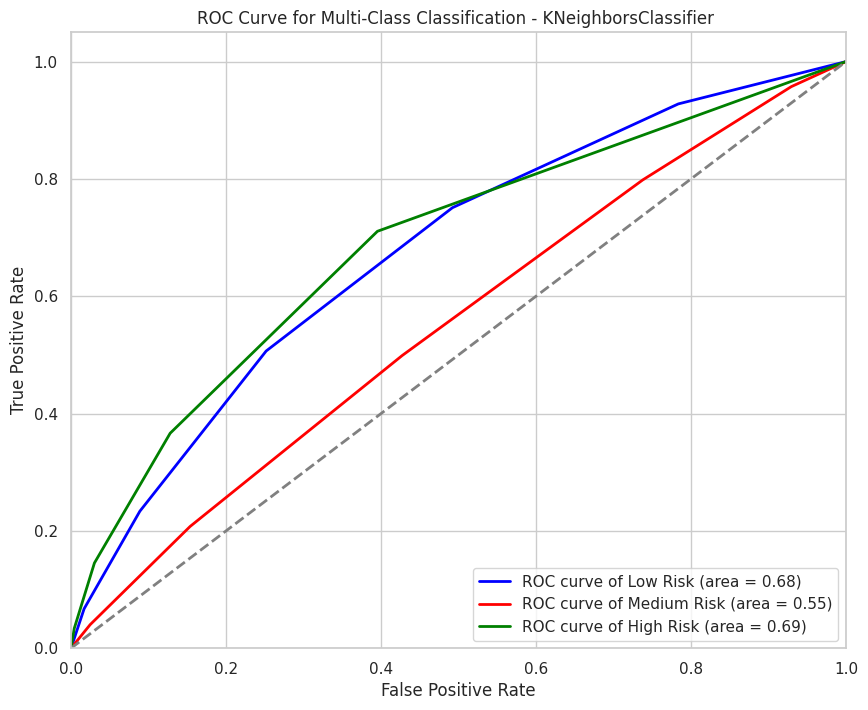

In [24]:
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk'] # Define risk labels for better readability

for name, model in models.items():
    # Construct a pipeline with shared preprocessing steps + the specific model
    pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           ('model', model)
                           ])
    # Train the pipeline
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    # prediction time
    predict_start_time = time.time()
    y_pred = pipeline.predict(X_test)
    predict_end_time = time.time()
    predict_time = predict_end_time - predict_start_time

    # Evaluate
    score = pipeline.score(X_test, y_test) # remember accuracy_score(y_test,y_pred)
    # and pipeline.score(X_test,y_test) are same only they differ how they operate
    train_accuracy = pipeline.score(X_train, y_train)
    recall = recall_score(y_test, pipeline.predict(X_test),average='micro')
    confusion_mat = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred, target_names=risk_labels)
    roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test), multi_class='ovr')
    metrics['F1'].append(f1_score(y_test, y_pred, average='micro'))
    metrics['Precision'].append(precision_score(y_test, y_pred, average='micro'))
    metrics['ROC AUC'].append(roc_auc)
    metrics['Confusion Matrix'].append(confusion_mat)
    metrics['Classification Report'].append(classification_rep)
    metrics['Model'].append(name)
    metrics['Test Accuracy'].append(score)
    metrics['Train Accuracy'].append(train_accuracy)
    metrics['Training Time'].append(train_time)
    metrics['Prediction Time'].append(predict_time)
    metrics['Recall'].append(recall)
    print(f"{name} Classification Report: {classification_rep}")

    #Lets draw the ROC AUC curve for each class

    # Binarize the output for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_binarized.shape[1]
    # Compute ROC curve and ROC area for each class
    y_prob_roc = pipeline.predict_proba(X_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob_roc[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Plot ROC curve for each class
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green']
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'ROC curve of {risk_labels[i]} (area = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Multi-Class Classification - {type(pipeline.named_steps['model']).__name__} ')
    plt.legend(loc="lower right")
    plt.show()

    # print(f"{name} Accuracy: {score:.4f}")

### Performance & Metrics evaluation of 4 models -- Basic evaluation

In [25]:
result_df_all_classifiers = pd.DataFrame(metrics)
result_df_all_classifiers

,Model,Training Time,Prediction Time,Train Accuracy,Test Accuracy,Recall,Confusion Matrix,Classification Report,ROC AUC,F1,Precision
0,LogisticRegression,0.53,0.04,0.61,0.60,0.60,"[[1084, 775, 12], [579, 1671, 115], [23, 510, ...",precision recall f1-score ...,0.76,0.60,0.60
1,SupportVectorMachine,135.95,5.35,0.64,0.59,0.59,"[[1029, 840, 2], [502, 1810, 53], [22, 610, 132]]",precision recall f1-score ...,0.75,0.59,0.59
2,DecisionTree,0.10,0.01,0.59,0.57,0.57,"[[864, 996, 11], [437, 1799, 129], [25, 547, 1...",precision recall f1-score ...,0.72,0.57,0.57
3,KNN,0.05,0.61,0.67,0.50,0.50,"[[1107, 741, 23], [971, 1289, 105], [159, 494,...",precision recall f1-score ...,0.64,0.50,0.50


# Results indicates generic classification algorithms are not showing good results. The accuracy and recall scores are NOT satisfatroy. For this use case we need higher recall score for LOW  MEDIUM & HIGH RISK patients inorder NOT to miss potential mental health RISK  pateients.

* ROC-AUC curves indicates out of these FOUR models LogisticRegression is better compared to KNN,SVM & DecisionTree

* AUC for LogisticRegression
Low Risk = 0.79
Medium Risk = 0.65
High Risk = 0.85

* Restricted DecisionTree to max_depth =5 to ensure it does not overfit.

* Recall score is more important than accuraccy score

*  **From overall performace(Train/Test time) and recall/precision/F1-score perspective I will take LogisticRegression as my base model & look for other algorithm that can handle class imbalance & non linear relationships in a better way**

# Next I will try with more robust classifies that handles class imbalance & overlapping features

## Define a function to train/test & evaluate metrices of different algorithms

- Models will be judged on below Evaluation Metrics

      1. Precision
      2. Recall
      3. F1-score
      4. ROC-AUC
      5. Performance (Training/Testing time)
      

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, sample_weights=None):
    # Train the model
    train_start_time = time.time()
    if sample_weights is not None:
        # Check if the model is RandomForestClassifier and has class_weight='balanced'
        # If so, sample_weights might interfere or be redundant. For consistency, we'll pass it.
        try:
            model.fit(X_train, y_train, model__sample_weight=sample_weights)
        except TypeError:
            # If model__sample_weight is not accepted (e.g., RandomForest with class_weight)
            model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)
    train_end_time = time.time()
    train_duration = train_end_time - train_start_time

    print(f"Model Name: {type(model.named_steps['model']).__name__}\n")
    print(f"Model training time: {train_duration:.2f} seconds")

    # Evaluate the model

    # Predict on the test set
    predict_start_time = time.time()
    y_pred = model.predict(X_test)
    predict_end_time = time.time()
    predict_duration = predict_end_time - predict_start_time


    print(f"Model prediction time: {predict_duration:.2f} seconds")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # 1. Get the predicted probabilities for each class
    y_prob_roc = model.predict_proba(X_test)

    # Calculate evaluation metrics
    metrics = {
        'Model': type(model.named_steps['model']).__name__,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train)),
        'Precision': precision_score(y_test, y_pred, average='micro'),
        'Recall': recall_score(y_test, y_pred, average='micro'),
        'F1': f1_score(y_test, y_pred, average='micro'),
        'ROC AUC': roc_auc_score(y_test, y_prob_roc, multi_class='ovr'),  # Use 'ovr' for multi-class classification
        "Training Time": train_duration,
        "Prediction Time": predict_duration
    }



    if (type(model.named_steps['model']).__name__ == 'RandomForestClassifier'):
        print(f"OOB Score: {model.named_steps['model'].oob_score_}")
#Draw the ROC AUC curve for each class

    # Binarize the output for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_binarized.shape[1]
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob_roc[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Plot ROC curve for each class
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green']
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Multi-Class Classification - {type(model.named_steps['model']).__name__} ')
    plt.legend(loc="lower right")
    plt.show()

    return pd.Series(metrics).round(3)

In [27]:
X = mental_health_engineered_final_df.drop(columns='mental_health_risk')
y = mental_health_engineered_final_df['mental_health_risk']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create class_weight & sample_weight to handle target class imbalance

## **The most imbalanced class - High Risk class**

### **The other moderately imbalanced class - Low Risk**




In [29]:
from sklearn.utils import class_weight

# Calculate class weights for 'class_weight' parameter in some models
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

# Calculate sample weights for models that accept 'sample_weight' argument
sample_weights_train = class_weight.compute_sample_weight(
    class_weights_dict,
    y_train
)

print("Class Weights Dictionary:", class_weights_dict)
print("Sample Weights (first 10 samples):")
print(sample_weights_train[:10])

Class Weights Dictionary: {np.int64(0): np.float64(0.890551251224508), np.int64(1): np.float64(0.704870656234581), np.int64(2): np.float64(2.181500872600349)}
Sample Weights (first 10 samples):
[0.70487066 0.89055125 0.89055125 0.70487066 0.89055125 0.70487066
 0.70487066 0.89055125 0.70487066 0.89055125]


## Logistic Regression pipeline

Model Name: LogisticRegression

Model training time: 0.64 seconds
Model prediction time: 0.03 seconds
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.67      0.64      1871
           1       0.57      0.38      0.46      2365
           2       0.38      0.70      0.49       764

    accuracy                           0.54      5000
   macro avg       0.52      0.58      0.53      5000
weighted avg       0.56      0.54      0.53      5000

Confusion Matrix:
[[1255  471  145]
 [ 740  895  730]
 [  36  193  535]]


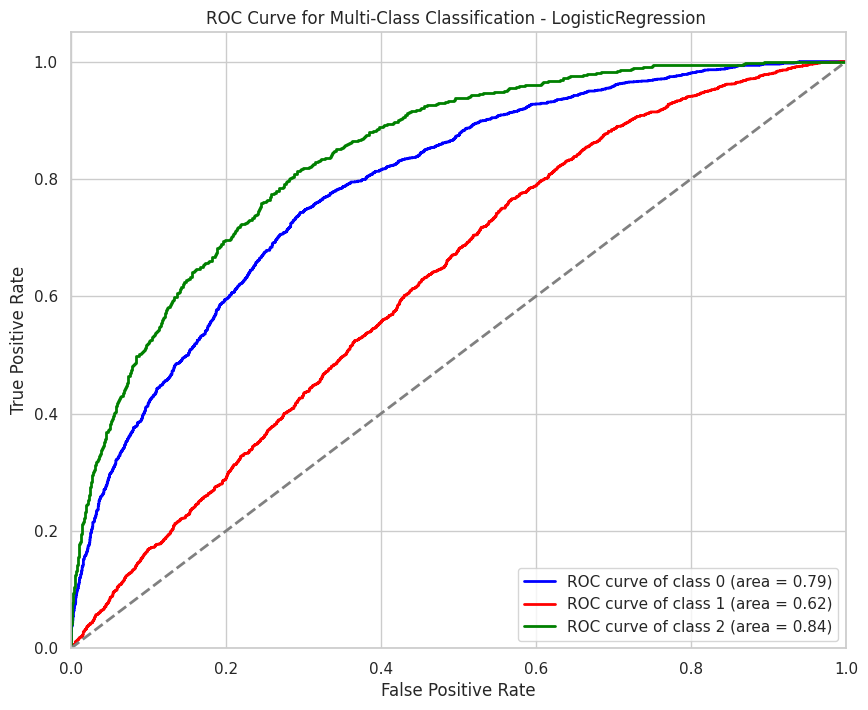


Evaluation Metrics:
Model              LogisticRegression
Test Accuracy                    0.54
Train Accuracy                   0.55
Precision                        0.54
Recall                           0.54
F1                               0.54
ROC AUC                          0.75
Training Time                    0.64
Prediction Time                  0.03
dtype: object


In [30]:
pipeline = Pipeline(
    (
     ('preprocessor', column_transformer),
     ('model', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200))  # Using Logistic Regression for classification
    )
)
results = train_and_evaluate_model(pipeline, X_train, y_train, X_test, y_test,sample_weights=sample_weights_train)
print("\nEvaluation Metrics:")
print(results)

# ROC_AUC curve indicates LogisticResgression able to predic  high RISK (2) mental patients indicating creating class_weights helped to handle the most imbalanced class (HIGH_RISK)

**Try other algorithms, if that improves scores across other classes**

*True Positive Rate (TPR), Sensitivity, and Recall are fundamentally the exact same metric in machine learning and statistics. They all measure the proportion of actual positive cases that a model correctly identifies*.

*This area-under-curve are less for "low Risk" and "medium Risk" compared to "high Risk". True Positive rate can be improved to catch low and medium Risk patients*.

***The PAIRPLOT above which indicates the features are overlapping and many has nonlinear relationship  hence  need more robust algorithm like RandomForest/GradientBoosting might  produce better results***

# Lets try two ensemble classifiers namely RandomForest & XGBoost

## RandomForest pipeline

Model Name: RandomForestClassifier

Model training time: 4.01 seconds
Model prediction time: 0.14 seconds
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.57      0.61      1871
           1       0.56      0.73      0.63      2365
           2       0.61      0.19      0.29       764

    accuracy                           0.59      5000
   macro avg       0.61      0.50      0.51      5000
weighted avg       0.60      0.59      0.57      5000

Confusion Matrix:
[[1070  793    8]
 [ 554 1727   84]
 [  33  585  146]]
OOB Score: 0.59005


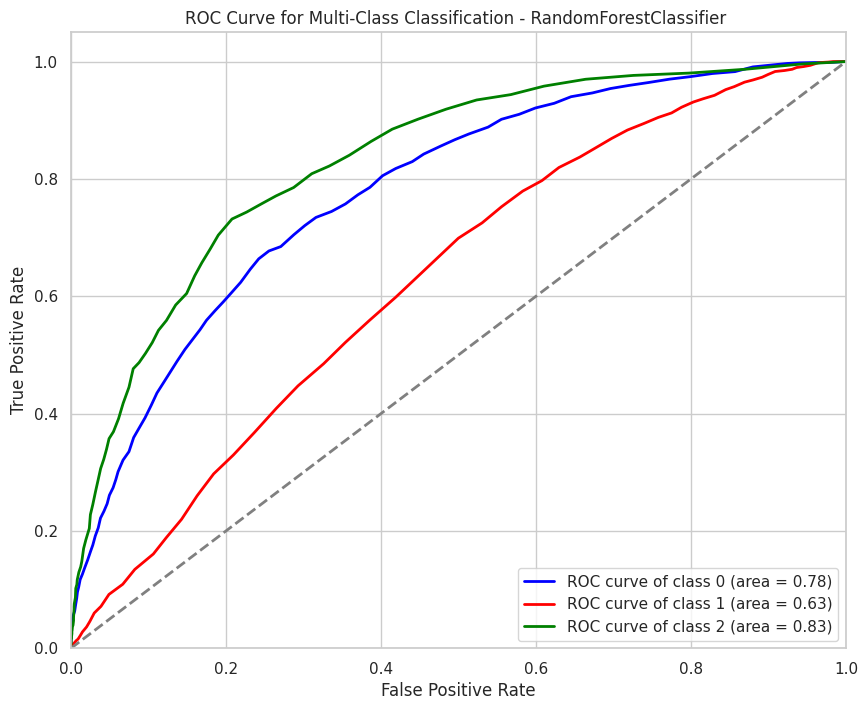


Evaluation Metrics for Random Forest:
Model              RandomForestClassifier
Test Accuracy                        0.59
Train Accuracy                       1.00
Precision                            0.59
Recall                               0.59
F1                                   0.59
ROC AUC                              0.75
Training Time                        4.01
Prediction Time                      0.14
dtype: object


In [31]:
rf_pipeline = Pipeline(
    (
     ('preprocessor', column_transformer),
     ('model', RandomForestClassifier(random_state=42, class_weight='balanced',oob_score=True))  # Using Random Forest for classification with balanced class weights
    )
)
results_rf = train_and_evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test)
print("\nEvaluation Metrics for Random Forest:")
print(results_rf)

## XGBoostClassifier  pipeline

Model Name: XGBClassifier

Model training time: 1.17 seconds
Model prediction time: 0.05 seconds
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.68      0.65      1871
           1       0.60      0.43      0.50      2365
           2       0.41      0.65      0.50       764

    accuracy                           0.56      5000
   macro avg       0.54      0.59      0.55      5000
weighted avg       0.58      0.56      0.56      5000

Confusion Matrix:
[[1278  461  132]
 [ 744 1019  602]
 [  43  221  500]]


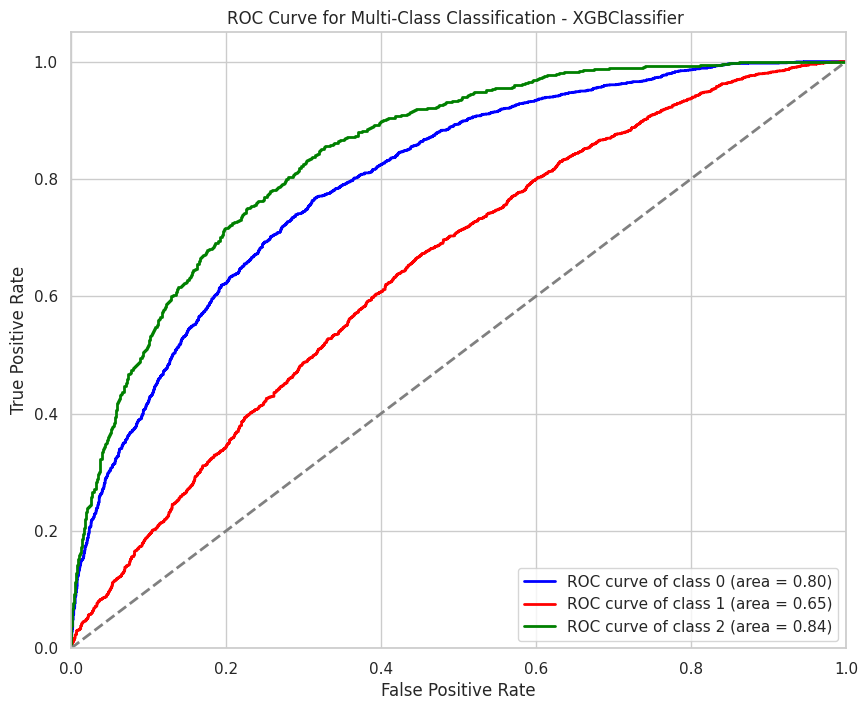


Evaluation Metrics for XGBoost:
Model              XGBClassifier
Test Accuracy               0.56
Train Accuracy              0.65
Precision                   0.56
Recall                      0.56
F1                          0.56
ROC AUC                     0.76
Training Time               1.17
Prediction Time             0.05
dtype: object


In [32]:
xgb_pipeline = Pipeline(
    (
     ('preprocessor', column_transformer),
     ('model',  xgb.XGBClassifier(n_estimators=100,
      objective='multi:softprob', # or 'multi:softprob'
      num_class=3,
      learning_rate=0.1) ) # Using XGBoost Classifier
    )
)
results_xgb = train_and_evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, sample_weights=sample_weights_train)
print("\nEvaluation Metrics for XGBoost:")
print(results_xgb)

# Build evaluation matrix for THREE algorithms

### LogisticRegression
### RandomForest
### XGboost

In [33]:
evaluation_results = pd.concat([results, results_rf, results_xgb], axis=1).T
evaluation_results.index = ['Logistic Regression', 'Random Forest', 'XGBoost']
display(evaluation_results)

,Model,Test Accuracy,Train Accuracy,Precision,Recall,F1,ROC AUC,Training Time,Prediction Time
Logistic Regression,LogisticRegression,0.54,0.55,0.54,0.54,0.54,0.75,0.64,0.03
Random Forest,RandomForestClassifier,0.59,1.00,0.59,0.59,0.59,0.75,4.01,0.14
XGBoost,XGBClassifier,0.56,0.65,0.56,0.56,0.56,0.76,1.17,0.05


<Figure size 1500x800 with 0 Axes>

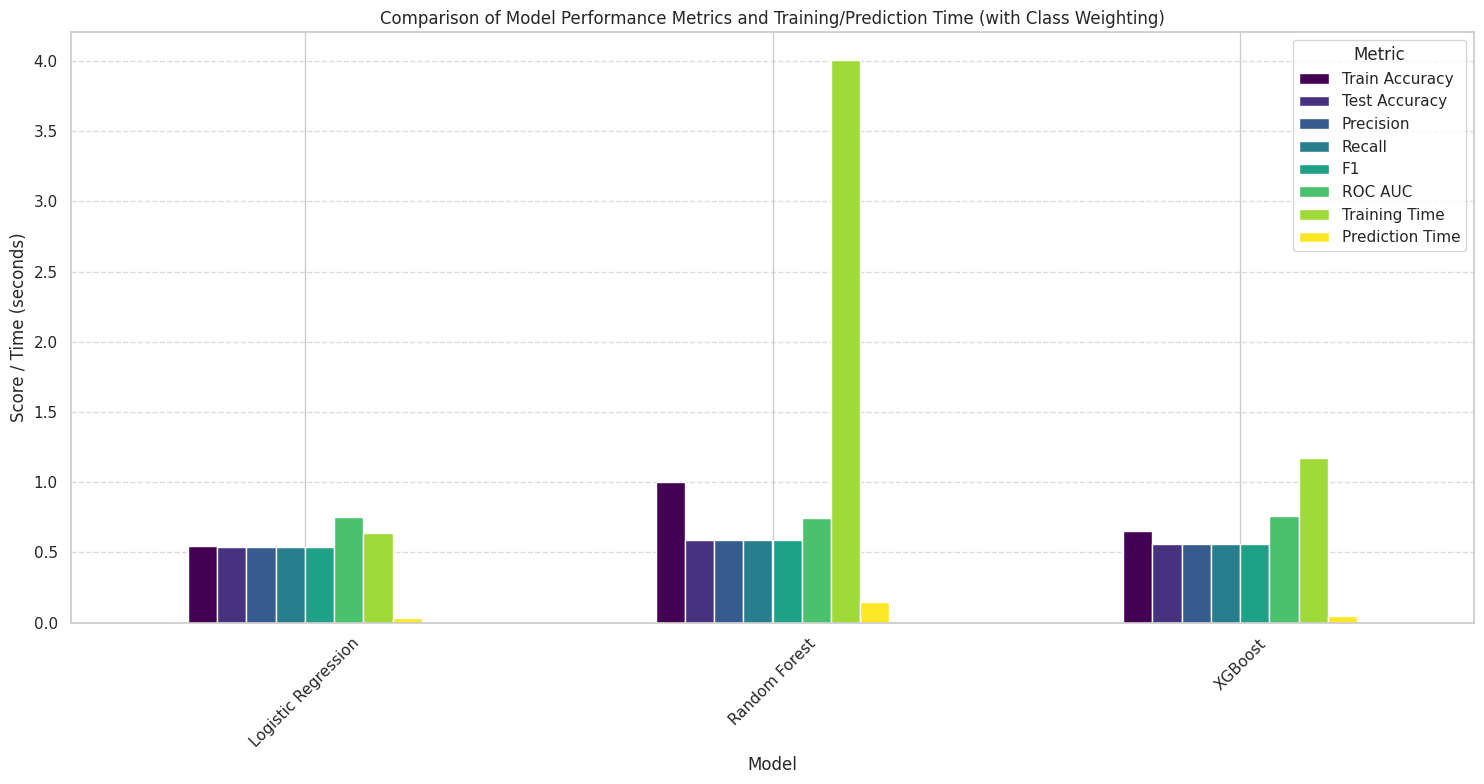

In [34]:
plt.figure(figsize=(15, 8))
evaluation_results[['Train Accuracy','Test Accuracy' ,'Precision', 'Recall', 'F1', 'ROC AUC', 'Training Time', 'Prediction Time']].plot(kind='bar', figsize=(15, 8), colormap='viridis', rot=45)
plt.title('Comparison of Model Performance Metrics and Training/Prediction Time (with Class Weighting)')
plt.xlabel('Model')
plt.ylabel('Score / Time (seconds)')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Observations :

1. RandomForest Training time is very high. Training accuracy = 1.0. Further investigation needed
2. XGClassifier & Logistic Regresion - although similar results, XGBoost slightly better in terms of Recall/Precision/ROC AUC
3. Hyper parameter Tuning needed to improve metrics


### Confusion Matrix Comparison on base pipelines **before** applying gridsearch optimization and threshhold tuning

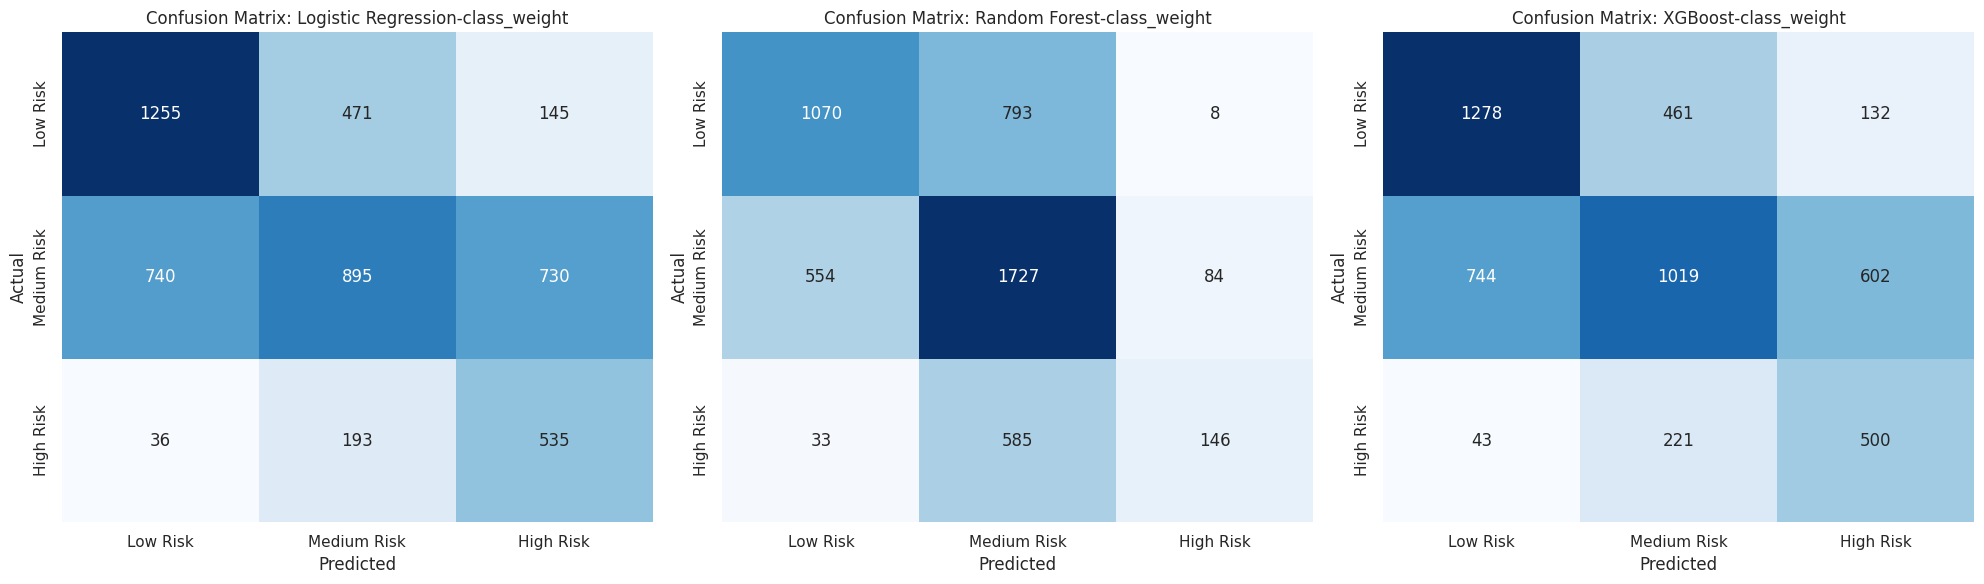

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, model_name, ax, class_labels=None):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix: {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if class_labels: # Set tick labels if provided
        ax.set_xticklabels(class_labels)
        ax.set_yticklabels(class_labels)

# Get predictions for each model
y_pred_lr = pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)

# Assuming y_test has values 0, 1, 2
class_labels = ['Low Risk', 'Medium Risk', 'High Risk']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression-class_weight', axes[0], class_labels=class_labels)
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest-class_weight', axes[1], class_labels=class_labels)
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost-class_weight', axes[2], class_labels=class_labels)

plt.tight_layout()
plt.show()

**Confusion Matrix Summary**:

Each confusion matrix shows how many instances of each actual risk level were predicted into each risk level by the model. The rows represent the actual classes, and the columns represent the predicted classes. Our classes are **Low Risk (0), Medium Risk (1), and High Risk (2)**.

**1. Logistic Regression (with Class Weighting)**
- Low Risk (Actual 0): The model correctly predicted 1255 out of 1871 actual Low Risk cases. However, a significant number (471) were incorrectly predicted as Medium Risk, and 145 were incorrectly predicted as High Risk.
- **Medium Risk (Actual 1):** The model correctly predicted 895 out of 2365 actual Medium Risk cases. A large number were misclassified as Low Risk (740) or High Risk (730).
- **High Risk (Actual 2):** The model showed a relatively better performance for High Risk, correctly predicting 535 out of 764 cases. Only 36 were misclassified as Low Risk, and 193 as Medium Risk.

***Overall:*** Logistic Regression struggled most with the Medium Risk class, misclassifying a large portion into both Low and High Risk. It performed best in identifying High Risk cases among the three classes.

**2. Random Forest (with Class Weighting)**

- **Low Risk (Actual 0):** The model correctly predicted 1070 out of 1871 actual Low Risk cases. A substantial portion (793) was misclassified as Medium Risk, with only 8 as High Risk.
- **Medium Risk (Actual 1):** The model correctly identified 1727 out of 2365 actual Medium Risk cases, showing better performance than Logistic Regression for this class. 554 were predicted as Low Risk, and 84 as High Risk.
- **High Risk (Actual 2):** The model correctly predicted 146 out of 764 actual High Risk cases, which is quite low. A large number (585) were misclassified as Medium Risk, and 33 as Low Risk.

***Overall:*** Random Forest showed improved performance for Medium Risk but struggled significantly with identifying High Risk cases, often predicting them as Medium Risk. It also had a notable number of Low Risk cases predicted as Medium Risk.


**3. XGBoost (with Class Weighting)**
- **Low Risk (Actual 0):** The model correctly predicted 1278 out of 1871 actual Low Risk cases. 461 were misclassified as Medium Risk, and 132 as High Risk.

- **Medium Risk (Actual 1):** The model correctly identified 1019 out of 2365 actual Medium Risk cases. 744 were misclassified as Low Risk, and 602 as High Risk.
- **High Risk (Actual 2):** The model correctly predicted 500 out of 764 actual High Risk cases. 43 were misclassified as Low Risk, and 221 as Medium Risk.

***Overall:*** XGBoost shows a balanced performance compared to the other two. It has a slightly better True Positive count for Low Risk than Logistic Regression and better performance for High Risk compared to Random Forest. The Medium Risk class remains challenging, with a substantial portion misclassified.

In general, before tuning, all models showed areas of significant misclassification, especially with the 'Medium Risk' class often being confused with 'Low' or 'High' risk. The 'High Risk' class recall is also a concern for Random Forest, where many were predicted as 'Medium Risk'.

### Hyperparameter Tuning for Random Forest using RandomizedSearchCV

In [36]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300], # number of trees
    'model__max_features': [5,8,10], # number of features to be used to split the nodes
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [ 2, 4, 6], # This reduces overfitting. indicates number of samples in leaf node
    'model__min_samples_split': [2, 5, 8]
}

'''grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)
'''
grid_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

print("Starting RandomSearchCV for Random Forest...")
grid_search_rf.fit(X_train, y_train)

print("RandomSearchCV for Random Forest completed.")

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
print("Best F1-macro score for Random Forest:", grid_search_rf.best_score_)

Starting RandomSearchCV for Random Forest...
RandomSearchCV for Random Forest completed.

Best parameters for Random Forest: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 6, 'model__max_features': 5, 'model__max_depth': 20}
Best F1-macro score for Random Forest: 0.5734201356812281


In [37]:
# XGBoost gridsearch is taking loner time
# Use randomized search instead of gridsearch for XGBoost


# Define the parameter grid for XGBoost
param_random_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7,10],
    'model__subsample': [0.6,0.8, 0.9],
    'model__colsample_bytree': [0.7,0.8 ,0.9], # 0.7 to 0.8: Ideal for mid-sized datasets. It adds slight variation across trees without risking the omission of important predictors
    'model__gamma': [0, 0.1, 0.2], # Regularization parameter. Value Range: [0, infty).
    # gamma: Makes the algorithm more aggressive. Trees can grow deeper to capture complex or specific patterns, increasing the risk of overfitting.
    'model__sample_weight': [None, sample_weights_train] # Sample weights for
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_random_grid_xgb,
    n_iter=50,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

print("Randomized Search for XGBoost completed.")
print("\nBest parameters for XGBoost:", random_search_xgb.best_params_)
print("Best F1-macro score for XGBoost:", random_search_xgb.best_score_)




Randomized Search for XGBoost completed.

Best parameters for XGBoost: {'model__subsample': 0.8, 'model__sample_weight': None, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}
Best F1-macro score for XGBoost: 0.5651085914668911


In [ ]:
param_random_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
    # Removed 'fit__model__sample_weight' as it's not a valid parameter for tuning in param_distributions
}

random_search_lr = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_random_grid_lr,
    n_iter=50,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

# If I intend to use sample_weights, pass them via fit_params to the .fit() method:
# random_search_lr.fit(X_train, y_train, model__sample_weight=sample_weights_train)
# Or, if I want to tune between using sample_weights and not, I might need a custom approach
# or use class_weight='balanced' in LogisticRegression's constructor if applicable.

random_search_lr.fit(X_train, y_train)

print("Randomized Search for Logistic Regression completed.")
print("\nBest parameters for Logistic Regression:", random_search_lr.best_params_)
print("Best F1-macro score for Logistic Regression:", random_search_lr.best_score_)

Randomized Search for Logistic Regression completed.

Best parameters for Logistic Regression: {'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 10}
Best F1-macro score for Logistic Regression: 0.55217074706774


# Findout best THREE  tuned Models

In [39]:
# Find best model from LogisticRegression, Randomforest & xgboost

best_rf_model = grid_search_rf.best_estimator_
# best_xgb_model = grid_search_xgb.best_estimator_
best_random_xgb_model = random_search_xgb.best_estimator_
best_lr_model = random_search_lr.best_estimator_


#print("Best Random Forest Model:", best_rf_model)
# print("Best XGBoost Model:", best_xgb_model)
# print("Best Random XGBoost Model:", best_random_xgb_model)
# print("Best Logistic Regression Model:", best_lr_model)


# Gridserach outcome


1. Starting RandomizedSearchCV for Random Forest...


Best parameters for Random Forest: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 6, 'model__max_features': 5, 'model__max_depth': 20}
Best F1-macro score for Random Forest: 0.5734201356812281

2. Randomized Search for XGBoost completed.

Best parameters for XGBoost: {'model__subsample': 0.8, 'model__sample_weight': None, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}
Best F1-macro score for XGBoost: 0.5651085914668911


3. Randomized Search for Logistic Regression completed.

Best parameters for Logistic Regression: {'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 10}
Best F1-macro score for Logistic Regression: 0.5520498745609491

**Considering Recall/ClassificationReport & the above factors , XGBoost continues to show slightly better performance with its optimized parameters compared to Random Forest & LogisticRegression.**

# Calculate & plot Recall/Training/Testing scores of 3 tuned algorithms

In [40]:
#compare prediction , recall score of randomforest and xgboost using gridsearch best model

rf_best_pred = best_rf_model.predict(X_test)
# xgb_best_pred = best_xgb_model.predict(X_test)
random_search_xgb_pred = best_random_xgb_model.predict(X_test)
random_search_lr_pred = best_lr_model.predict(X_test)

rf_best_recall = recall_score(y_test, rf_best_pred, average='micro')
# xgb_best_recall = recall_score(y_test, xgb_best_pred, average='micro')
random_search_xgb_recall = recall_score(y_test, random_search_xgb_pred, average='micro')
random_search_lr_recall = recall_score(y_test, random_search_lr_pred, average='micro')

print("Random Forest Best Recall:", rf_best_recall)
# print("XGBoost Best Recall:", xgb_best_recall)
print("Randomized Search XGBoost Recall:", random_search_xgb_recall)
print("Randomized Search Logistic Regression Recall:", random_search_lr_recall)

# accuracy test & training socre of both gridsearch

rf_best_train_score = best_rf_model.score(X_train, y_train)
rf_best_test_score = best_rf_model.score(X_test, y_test)
# xgb_best_train_score = best_xgb_model.score(X_train, y_train)
# xgb_best_test_score = best_xgb_model.score(X_test, y_test)
xgb_best_train_score = best_random_xgb_model.score(X_train, y_train)
xgb_best_test_score = best_random_xgb_model.score(X_test, y_test)
lr_best_train_score = best_lr_model.score(X_train, y_train)
lr_best_test_score = best_lr_model.score(X_test, y_test)

print("Random Forest Best Train Score:", rf_best_train_score)
print("Random Forest Best Test Score:", rf_best_test_score)
print("Randomized Search XGBoost Train Score:", xgb_best_train_score)
print("Randomized Search XGBoost Test Score:", xgb_best_test_score)
print("Randomized Search Logistic Regression Train Score:", lr_best_train_score)
print("Randomized Search Logistic Regression Test Score:", lr_best_test_score)




Random Forest Best Recall: 0.586
Randomized Search XGBoost Recall: 0.611
Randomized Search Logistic Regression Recall: 0.5966
Random Forest Best Train Score: 0.8275
Random Forest Best Test Score: 0.586
Randomized Search XGBoost Train Score: 0.6482
Randomized Search XGBoost Test Score: 0.611
Randomized Search Logistic Regression Train Score: 0.6065
Randomized Search Logistic Regression Test Score: 0.5966


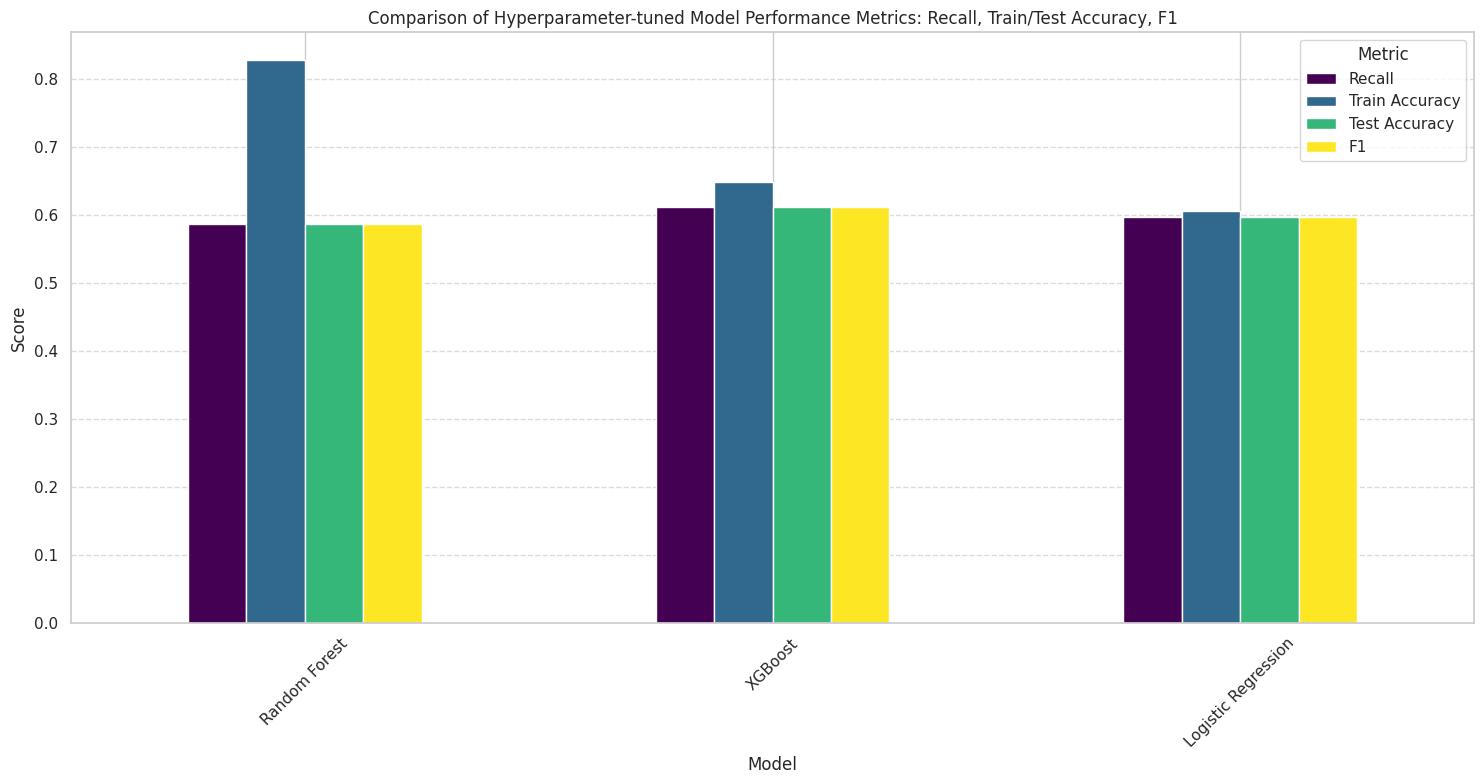

In [41]:
from sklearn.metrics import f1_score

# Calculate F1 scores for the best models
rf_best_f1 = f1_score(y_test, rf_best_pred, average='micro')
xgb_best_f1 = f1_score(y_test, random_search_xgb_pred, average='micro')
lr_best_f1 = f1_score(y_test, random_search_lr_pred, average='micro')

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Recall': [rf_best_recall, random_search_xgb_recall, random_search_lr_recall],
    'Train Accuracy': [rf_best_train_score, xgb_best_train_score, lr_best_train_score],
    'Test Accuracy': [rf_best_test_score, xgb_best_test_score, lr_best_test_score],
    'F1': [rf_best_f1, xgb_best_f1, lr_best_f1]
},
    index=['Random Forest', 'XGBoost', 'Logistic Regression']
)

plt.figure(figsize=(15, 8))
plot_data[['Recall', 'Train Accuracy', 'Test Accuracy', 'F1']].plot(kind='bar', figsize=(15, 8), colormap='viridis', rot=45, ax=plt.gca())

plt.title('Comparison of Hyperparameter-tuned Model Performance Metrics: Recall, Train/Test Accuracy, F1')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Best gridsearch model(LogisticRegresion, RandomForest & Xgboost)- Confusion matrix- BEFORE THRESHOLD TUNING

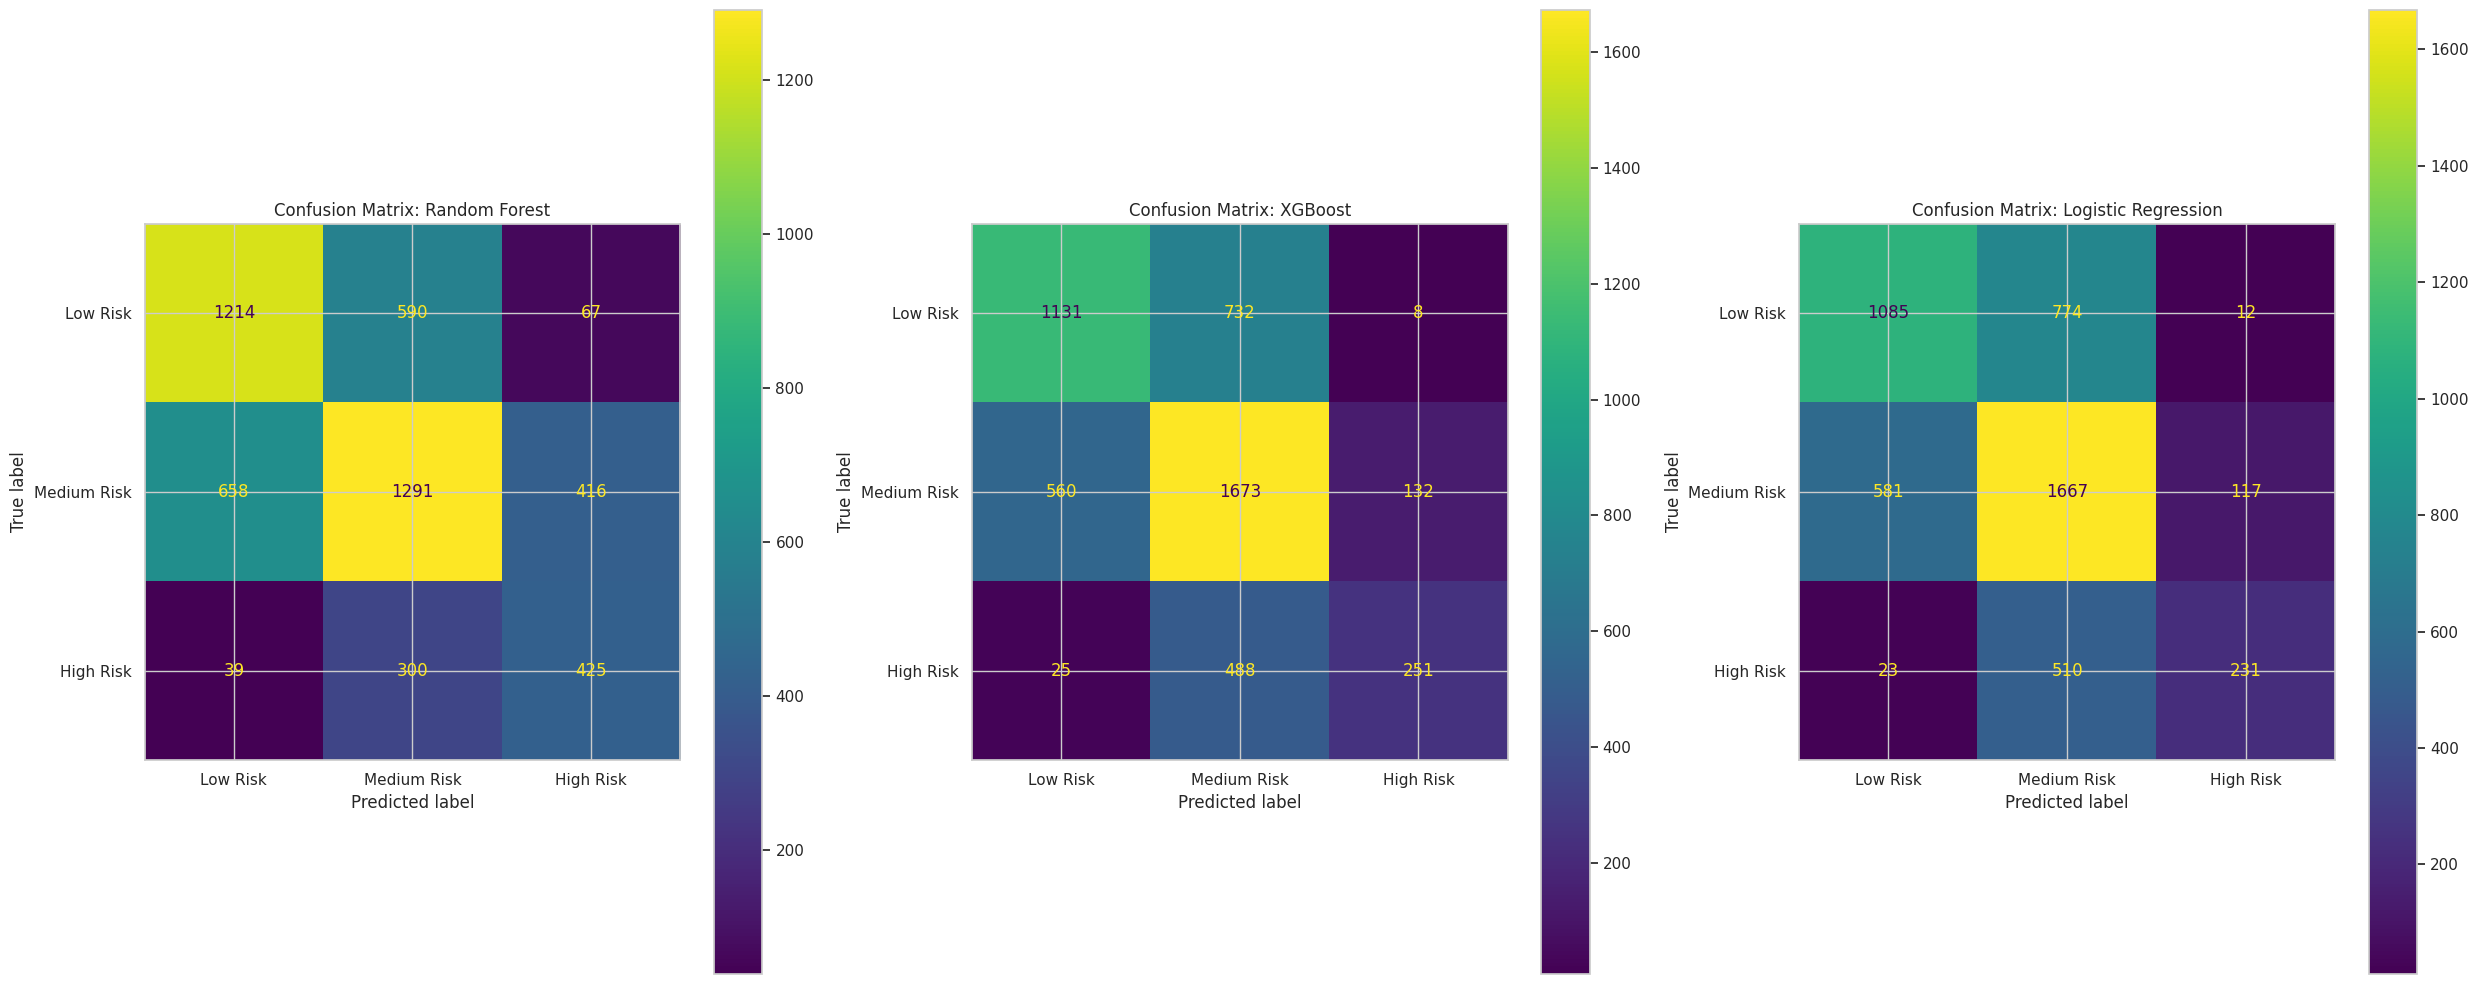

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Changed to 1 row, 3 columns to accommodate three plots, and adjusted figsize
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

# Assuming 'risk_labels' is defined in the environment (e.g., ['Low Risk', 'Medium Risk', 'High Risk'])
# If not, I might need to define it or fetch from y_test unique values

ConfusionMatrixDisplay.from_predictions(y_test, rf_best_pred, display_labels=risk_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix: Random Forest')
ConfusionMatrixDisplay.from_predictions(y_test, random_search_xgb_pred, display_labels=risk_labels, ax=axes[1])
axes[1].set_title('Confusion Matrix: XGBoost')
ConfusionMatrixDisplay.from_predictions(y_test, random_search_lr_pred, display_labels=risk_labels, ax=axes[2])
axes[2].set_title('Confusion Matrix: Logistic Regression')

plt.tight_layout()
plt.show()

### Custom Threshold Adjustment for Multi-Class Classification

To correctly adjust thresholds for specific classes in a multi-class problem, we need to consider the probabilities of all classes and modify the prediction logic. The following function `custom_predict_with_threshold` allows  to specify a threshold for a particular class. If the probability of that class exceeds the given threshold, it will be predicted as that class, overriding the default `argmax` behavior for that sample. If not, the default `argmax` prediction is used. This helps to increase the recall for the prioritized class.

Note that this is a simple example. More sophisticated strategies might involve setting different thresholds for multiple classes or more complex decision rules.

In [54]:
def custom_predict_with_threshold(model, X, target_class, threshold):
    # Get probabilities for all classes
    probabilities = model.predict_proba(X)

    # Initialize predictions with the default (argmax)
    y_pred = np.argmax(probabilities, axis=1)

    # Apply custom thresholding for the target class
    # If the probability of the target_class is above the threshold,
    # predict that class. If there's a tie, argmax logic would apply for others,
    # but here we prioritize the target_class if its probability is met.
    y_pred[probabilities[:, target_class] >= threshold] = target_class

    return y_pred


# Define the thresholds and the target class to prioritize
# We will test a range of thresholds for each of the three classes.

# Thresholds to test
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk'] # For better printing

# Initialize variables to store the best results for each optimization goal (Recall, F1, Precision)
# For Random Forest
best_rf_recall_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

best_rf_f1_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

best_rf_precision_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

# For XGBoost
best_xgb_recall_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

best_xgb_f1_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

best_xgb_precision_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

# For Logistic Regression
best_lr_recall_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

best_lr_f1_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

best_lr_precision_results = {
    0: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    1: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
    2: {'target_class_recall': -1, 'f1_score_target_class': -1, 'precision_score_target_class': -1, 'threshold': -1, 'micro_recall': -1, 'macro_recall': -1},
}

# Data structures to store all precision and recall values for plotting trade-offs
rf_pr_curves = {i: {'precision': [], 'recall': [], 'threshold': []} for i in range(3)}
xgb_pr_curves = {i: {'precision': [], 'recall': [], 'threshold': []} for i in range(3)}
lr_pr_curves = {i: {'precision': [], 'recall': [], 'threshold': []} for i in range(3)}

for class_idx in range(3): # Iterate for classes 0, 1, 2
    # print(f"\n--- Adjusting Threshold for {risk_labels[class_idx]} (Class {class_idx}) ---")
    for t in thresholds:
        rf_pred = custom_predict_with_threshold(best_rf_model, X_test, target_class=class_idx, threshold=t)
        xgb_pred = custom_predict_with_threshold(best_random_xgb_model, X_test, target_class=class_idx, threshold=t)
        lr_pred = custom_predict_with_threshold(best_lr_model, X_test, target_class=class_idx, threshold=t)

        # Calculate recall for the specific target class, and overall micro/macro recall
        rf_recall_per_class = recall_score(y_test, rf_pred, average=None)
        xgb_recall_per_class = recall_score(y_test, xgb_pred, average=None)
        lr_recall_per_class = recall_score(y_test, lr_pred, average=None)

        rf_micro_recall = recall_score(y_test, rf_pred, average='micro')
        xgb_micro_recall = recall_score(y_test, xgb_pred, average='micro')
        lr_micro_recall = recall_score(y_test, lr_pred, average='micro')

        rf_macro_recall = recall_score(y_test, rf_pred, average='macro')
        xgb_macro_recall = recall_score(y_test, xgb_pred, average='macro')
        lr_macro_recall = recall_score(y_test, lr_pred, average='macro')

        # Calculate F1 score and Precision for the specific target class
        rf_f1_per_class = f1_score(y_test, rf_pred, average=None)
        xgb_f1_per_class = f1_score(y_test, xgb_pred, average=None)
        lr_f1_per_class = f1_score(y_test, lr_pred, average=None)

        rf_precision_per_class = precision_score(y_test, rf_pred, average=None)
        xgb_precision_per_class = precision_score(y_test, xgb_pred, average=None)
        lr_precision_per_class = precision_score(y_test, lr_pred, average=None)

        # print(f"Threshold for Class {class_idx}: {t:.1f}")
        # print(f"  Random Forest - Recall (Class {class_idx}): {rf_recall_per_class[class_idx]:.4f}, F1 (Class {class_idx}): {rf_f1_per_class[class_idx]:.4f}, Precision (Class {class_idx}): {rf_precision_per_class[class_idx]:.4f}, Micro Recall: {rf_micro_recall:.4f}, Macro Recall: {rf_macro_recall:.4f}")
        # print(f"  XGBoost - Recall (Class {class_idx}): {xgb_recall_per_class[class_idx]:.4f}, F1 (Class {class_idx}): {xgb_f1_per_class[class_idx]:.4f}, Precision (Class {class_idx}): {xgb_precision_per_class[class_idx]:.4f}, Micro Recall: {xgb_micro_recall:.4f}, Macro Recall: {xgb_macro_recall:.4f}")
        # print(f"  Logistic Regression - Recall (Class {class_idx}): {lr_recall_per_class[class_idx]:.4f}, F1 (Class {class_idx}): {lr_f1_per_class[class_idx]:.4f}, Precision (Class {class_idx}): {lr_precision_per_class[class_idx]:.4f}, Micro Recall: {lr_micro_recall:.4f}, Macro Recall: {lr_macro_recall:.4f}")

        # Store all values for PR curve plotting
        rf_pr_curves[class_idx]['precision'].append(rf_precision_per_class[class_idx])
        rf_pr_curves[class_idx]['recall'].append(rf_recall_per_class[class_idx])
        rf_pr_curves[class_idx]['threshold'].append(t)

        xgb_pr_curves[class_idx]['precision'].append(xgb_precision_per_class[class_idx])
        xgb_pr_curves[class_idx]['recall'].append(xgb_recall_per_class[class_idx])
        xgb_pr_curves[class_idx]['threshold'].append(t)

        lr_pr_curves[class_idx]['precision'].append(lr_precision_per_class[class_idx])
        lr_pr_curves[class_idx]['recall'].append(lr_recall_per_class[class_idx])
        lr_pr_curves[class_idx]['threshold'].append(t)

        # Update best_rf_recall_results if current target_class_recall is better
        if rf_recall_per_class[class_idx] > best_rf_recall_results[class_idx]['target_class_recall']:
            best_rf_recall_results[class_idx]['target_class_recall'] = rf_recall_per_class[class_idx]
            best_rf_recall_results[class_idx]['f1_score_target_class'] = rf_f1_per_class[class_idx]
            best_rf_recall_results[class_idx]['precision_score_target_class'] = rf_precision_per_class[class_idx]
            best_rf_recall_results[class_idx]['threshold'] = t
            best_rf_recall_results[class_idx]['micro_recall'] = rf_micro_recall
            best_rf_recall_results[class_idx]['macro_recall'] = rf_macro_recall

        # Update best_rf_f1_results if current target_class_f1 is better
        if rf_f1_per_class[class_idx] > best_rf_f1_results[class_idx]['f1_score_target_class']:
            best_rf_f1_results[class_idx]['target_class_recall'] = rf_recall_per_class[class_idx]
            best_rf_f1_results[class_idx]['f1_score_target_class'] = rf_f1_per_class[class_idx]
            best_rf_f1_results[class_idx]['precision_score_target_class'] = rf_precision_per_class[class_idx]
            best_rf_f1_results[class_idx]['threshold'] = t
            best_rf_f1_results[class_idx]['micro_recall'] = rf_micro_recall
            best_rf_f1_results[class_idx]['macro_recall'] = rf_macro_recall

        # Update best_rf_precision_results if current target_class_precision is better
        if rf_precision_per_class[class_idx] > best_rf_precision_results[class_idx]['precision_score_target_class']:
            best_rf_precision_results[class_idx]['target_class_recall'] = rf_recall_per_class[class_idx]
            best_rf_precision_results[class_idx]['f1_score_target_class'] = rf_f1_per_class[class_idx]
            best_rf_precision_results[class_idx]['precision_score_target_class'] = rf_precision_per_class[class_idx]
            best_rf_precision_results[class_idx]['threshold'] = t
            best_rf_precision_results[class_idx]['micro_recall'] = rf_micro_recall
            best_rf_precision_results[class_idx]['macro_recall'] = rf_macro_recall

        # Update best_xgb_recall_results if current target_class_recall is better
        if xgb_recall_per_class[class_idx] > best_xgb_recall_results[class_idx]['target_class_recall']:
            best_xgb_recall_results[class_idx]['target_class_recall'] = xgb_recall_per_class[class_idx]
            best_xgb_recall_results[class_idx]['f1_score_target_class'] = xgb_f1_per_class[class_idx]
            best_xgb_recall_results[class_idx]['precision_score_target_class'] = xgb_precision_per_class[class_idx]
            best_xgb_recall_results[class_idx]['threshold'] = t
            best_xgb_recall_results[class_idx]['micro_recall'] = xgb_micro_recall
            best_xgb_recall_results[class_idx]['macro_recall'] = xgb_macro_recall

        # Update best_xgb_f1_results if current target_class_f1 is better
        if xgb_f1_per_class[class_idx] > best_xgb_f1_results[class_idx]['f1_score_target_class']:
            best_xgb_f1_results[class_idx]['target_class_recall'] = xgb_recall_per_class[class_idx]
            best_xgb_f1_results[class_idx]['f1_score_target_class'] = xgb_f1_per_class[class_idx]
            best_xgb_f1_results[class_idx]['precision_score_target_class'] = xgb_precision_per_class[class_idx]
            best_xgb_f1_results[class_idx]['threshold'] = t
            best_xgb_f1_results[class_idx]['micro_recall'] = xgb_micro_recall
            best_xgb_f1_results[class_idx]['macro_recall'] = xgb_macro_recall

        # Update best_xgb_precision_results if current target_class_precision is better
        if xgb_precision_per_class[class_idx] > best_xgb_precision_results[class_idx]['precision_score_target_class']:
            best_xgb_precision_results[class_idx]['target_class_recall'] = xgb_recall_per_class[class_idx]
            best_xgb_precision_results[class_idx]['f1_score_target_class'] = xgb_f1_per_class[class_idx]
            best_xgb_precision_results[class_idx]['precision_score_target_class'] = xgb_precision_per_class[class_idx]
            best_xgb_precision_results[class_idx]['threshold'] = t
            best_xgb_precision_results[class_idx]['micro_recall'] = xgb_micro_recall
            best_xgb_precision_results[class_idx]['macro_recall'] = xgb_macro_recall

        # Update best_lr_recall_results if current target_class_recall is better
        if lr_recall_per_class[class_idx] > best_lr_recall_results[class_idx]['target_class_recall']:
            best_lr_recall_results[class_idx]['target_class_recall'] = lr_recall_per_class[class_idx]
            best_lr_recall_results[class_idx]['f1_score_target_class'] = lr_f1_per_class[class_idx]
            best_lr_recall_results[class_idx]['precision_score_target_class'] = lr_precision_per_class[class_idx]
            best_lr_recall_results[class_idx]['threshold'] = t
            best_lr_recall_results[class_idx]['micro_recall'] = lr_micro_recall
            best_lr_recall_results[class_idx]['macro_recall'] = lr_macro_recall

        # Update best_lr_f1_results if current target_class_f1 is better
        if lr_f1_per_class[class_idx] > best_lr_f1_results[class_idx]['f1_score_target_class']:
            best_lr_f1_results[class_idx]['target_class_recall'] = lr_recall_per_class[class_idx]
            best_lr_f1_results[class_idx]['f1_score_target_class'] = lr_f1_per_class[class_idx]
            best_lr_f1_results[class_idx]['precision_score_target_class'] = lr_precision_per_class[class_idx]
            best_lr_f1_results[class_idx]['threshold'] = t
            best_lr_f1_results[class_idx]['micro_recall'] = lr_micro_recall
            best_lr_f1_results[class_idx]['macro_recall'] = lr_macro_recall

        # Update best_lr_precision_results if current target_class_precision is better
        if lr_precision_per_class[class_idx] > best_lr_precision_results[class_idx]['precision_score_target_class']:
            best_lr_precision_results[class_idx]['target_class_recall'] = lr_recall_per_class[class_idx]
            best_lr_precision_results[class_idx]['f1_score_target_class'] = lr_f1_per_class[class_idx]
            best_lr_precision_results[class_idx]['precision_score_target_class'] = lr_precision_per_class[class_idx]
            best_lr_precision_results[class_idx]['threshold'] = t
            best_lr_precision_results[class_idx]['micro_recall'] = lr_micro_recall
            best_lr_precision_results[class_idx]['macro_recall'] = lr_macro_recall
    print()


# PRINT BEST RESULTS

In [44]:
model_names = ['Random Forest', 'XGBoost', 'Logistic Regression']
optimization_goals = ['Recall', 'F1', 'Precision']
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']

all_results = []

for class_idx in range(3):
    # Random Forest
    all_results.append({
        'Model': 'Random Forest',
        'Optimization Goal': f'Max Recall (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_rf_recall_results[class_idx]['threshold'],
        'Target Class Recall': best_rf_recall_results[class_idx]['target_class_recall'],
        'Target Class F1': best_rf_recall_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_rf_recall_results[class_idx]['precision_score_target_class']
    })
    all_results.append({
        'Model': 'Random Forest',
        'Optimization Goal': f'Max F1 (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_rf_f1_results[class_idx]['threshold'],
        'Target Class Recall': best_rf_f1_results[class_idx]['target_class_recall'],
        'Target Class F1': best_rf_f1_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_rf_f1_results[class_idx]['precision_score_target_class']
    })
    all_results.append({
        'Model': 'Random Forest',
        'Optimization Goal': f'Max Precision (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_rf_precision_results[class_idx]['threshold'],
        'Target Class Recall': best_rf_precision_results[class_idx]['target_class_recall'],
        'Target Class F1': best_rf_precision_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_rf_precision_results[class_idx]['precision_score_target_class']
    })

    # XGBoost
    all_results.append({
        'Model': 'XGBoost',
        'Optimization Goal': f'Max Recall (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_xgb_recall_results[class_idx]['threshold'],
        'Target Class Recall': best_xgb_recall_results[class_idx]['target_class_recall'],
        'Target Class F1': best_xgb_recall_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_xgb_recall_results[class_idx]['precision_score_target_class']
    })
    all_results.append({
        'Model': 'XGBoost',
        'Optimization Goal': f'Max F1 (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_xgb_f1_results[class_idx]['threshold'],
        'Target Class Recall': best_xgb_f1_results[class_idx]['target_class_recall'],
        'Target Class F1': best_xgb_f1_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_xgb_f1_results[class_idx]['precision_score_target_class']
    })
    all_results.append({
        'Model': 'XGBoost',
        'Optimization Goal': f'Max Precision (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_xgb_precision_results[class_idx]['threshold'],
        'Target Class Recall': best_xgb_precision_results[class_idx]['target_class_recall'],
        'Target Class F1': best_xgb_precision_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_xgb_precision_results[class_idx]['precision_score_target_class']
    })

    # Logistic Regression
    all_results.append({
        'Model': 'Logistic Regression',
        'Optimization Goal': f'Max Recall (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_lr_recall_results[class_idx]['threshold'],
        'Target Class Recall': best_lr_recall_results[class_idx]['target_class_recall'],
        'Target Class F1': best_lr_recall_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_lr_recall_results[class_idx]['precision_score_target_class']
    })
    all_results.append({
        'Model': 'Logistic Regression',
        'Optimization Goal': f'Max F1 (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_lr_f1_results[class_idx]['threshold'],
        'Target Class Recall': best_lr_f1_results[class_idx]['target_class_recall'],
        'Target Class F1': best_lr_f1_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_lr_f1_results[class_idx]['precision_score_target_class']
    })
    all_results.append({
        'Model': 'Logistic Regression',
        'Optimization Goal': f'Max Precision (Class {risk_labels[class_idx]})',
        'Target Class': risk_labels[class_idx],
        'Threshold': best_lr_precision_results[class_idx]['threshold'],
        'Target Class Recall': best_lr_precision_results[class_idx]['target_class_recall'],
        'Target Class F1': best_lr_precision_results[class_idx]['f1_score_target_class'],
        'Target Class Precision': best_lr_precision_results[class_idx]['precision_score_target_class']
    })

results_df = pd.DataFrame(all_results)
results_df_styled = results_df.style.format({
    'Threshold': '{:.1f}',
    'Target Class Recall': '{:.4f}',
    'Target Class F1': '{:.4f}',
    'Target Class Precision': '{:.4f}'
})
display(results_df_styled)

,Model,Optimization Goal,Target Class,Threshold,Target Class Recall,Target Class F1,Target Class Precision
0,Random Forest,Max Recall (Class Low Risk),Low Risk,0.1,0.9914,0.5816,0.4115
1,Random Forest,Max F1 (Class Low Risk),Low Risk,0.3,0.8220,0.6568,0.5469
2,Random Forest,Max Precision (Class Low Risk),Low Risk,0.5,0.6489,0.6420,0.6353
3,XGBoost,Max Recall (Class Low Risk),Low Risk,0.1,0.9727,0.6056,0.4396
4,XGBoost,Max F1 (Class Low Risk),Low Risk,0.3,0.8226,0.6674,0.5615
5,XGBoost,Max Precision (Class Low Risk),Low Risk,0.5,0.6045,0.6306,0.6591
6,Logistic Regression,Max Recall (Class Low Risk),Low Risk,0.1,0.9754,0.5937,0.4267
7,Logistic Regression,Max F1 (Class Low Risk),Low Risk,0.3,0.8177,0.6550,0.5462
8,Logistic Regression,Max Precision (Class Low Risk),Low Risk,0.5,0.5799,0.6096,0.6424
9,Random Forest,Max Recall (Class Medium Risk),Medium Risk,0.1,1.0000,0.6455,0.4765


### Evaluation of Best Thresholds

From the detailed breakdown of threshold optimization for Random Forest, XGBoost, and Logistic Regression across 'Low Risk', 'Medium Risk', and 'High Risk' classes, we can observe the following:

*   **Prioritizing Recall (e.g., for 'High Risk' or 'Low Risk' classes):** To maximize recall for a specific class, models generally require lower probability thresholds for that class. For instance, to achieve the highest recall for 'High Risk' (Class 2), thresholds of `0.1` are often selected across all models, leading to high recall but often at the cost of lower precision and F1-score for that specific class, and lower overall micro/macro recall.

*   **Prioritizing F1-score:** Optimizing for F1-score aims to balance precision and recall. The thresholds for maximizing F1-score tend to be in the `0.2` to `0.4` range, providing a compromise where both false positives and false negatives are considered. For example, XGBoost generally shows strong F1-scores for 'Medium Risk' and 'High Risk' in the `0.2` to `0.3` threshold range.

*   **Prioritizing Precision:** To achieve high precision for a class (meaning fewer false positives), higher probability thresholds are usually selected (e.g., `0.5`). This ensures that when the model predicts a certain class, it is highly likely to be correct, but it might miss many actual positive cases, leading to lower recall.

*   **Model Comparison:**
    *   **Random Forest** tends to achieve very high recall for the 'Low Risk' and 'Medium Risk' classes at low thresholds, but its precision for these cases can be lower. It shows reasonable balance when optimizing for F1-score.
    *   **XGBoost** often demonstrates a good balance between recall and precision, especially when optimizing for F1-score across different classes. It generally provides competitive performance.
    *   **Logistic Regression** can achieve very high recall for 'Low Risk' and 'Medium Risk' at low thresholds, similar to Random Forest. When optimizing for precision, it can be quite effective for the 'High Risk' class, but like other models, this comes with a trade-off in recall.

Overall, the choice of threshold heavily depends on the specific business objective: whether it's more critical to identify as many true positives as possible (high recall), to minimize false positives (high precision), or to strike a balance between the two (high F1-score). The plots visually reinforce these trade-offs, showing how moving the threshold impacts these metrics.

# Visualization Precision VS Recall trade off at different thresholds -XGBoost/RandomForest/LogisticRegression

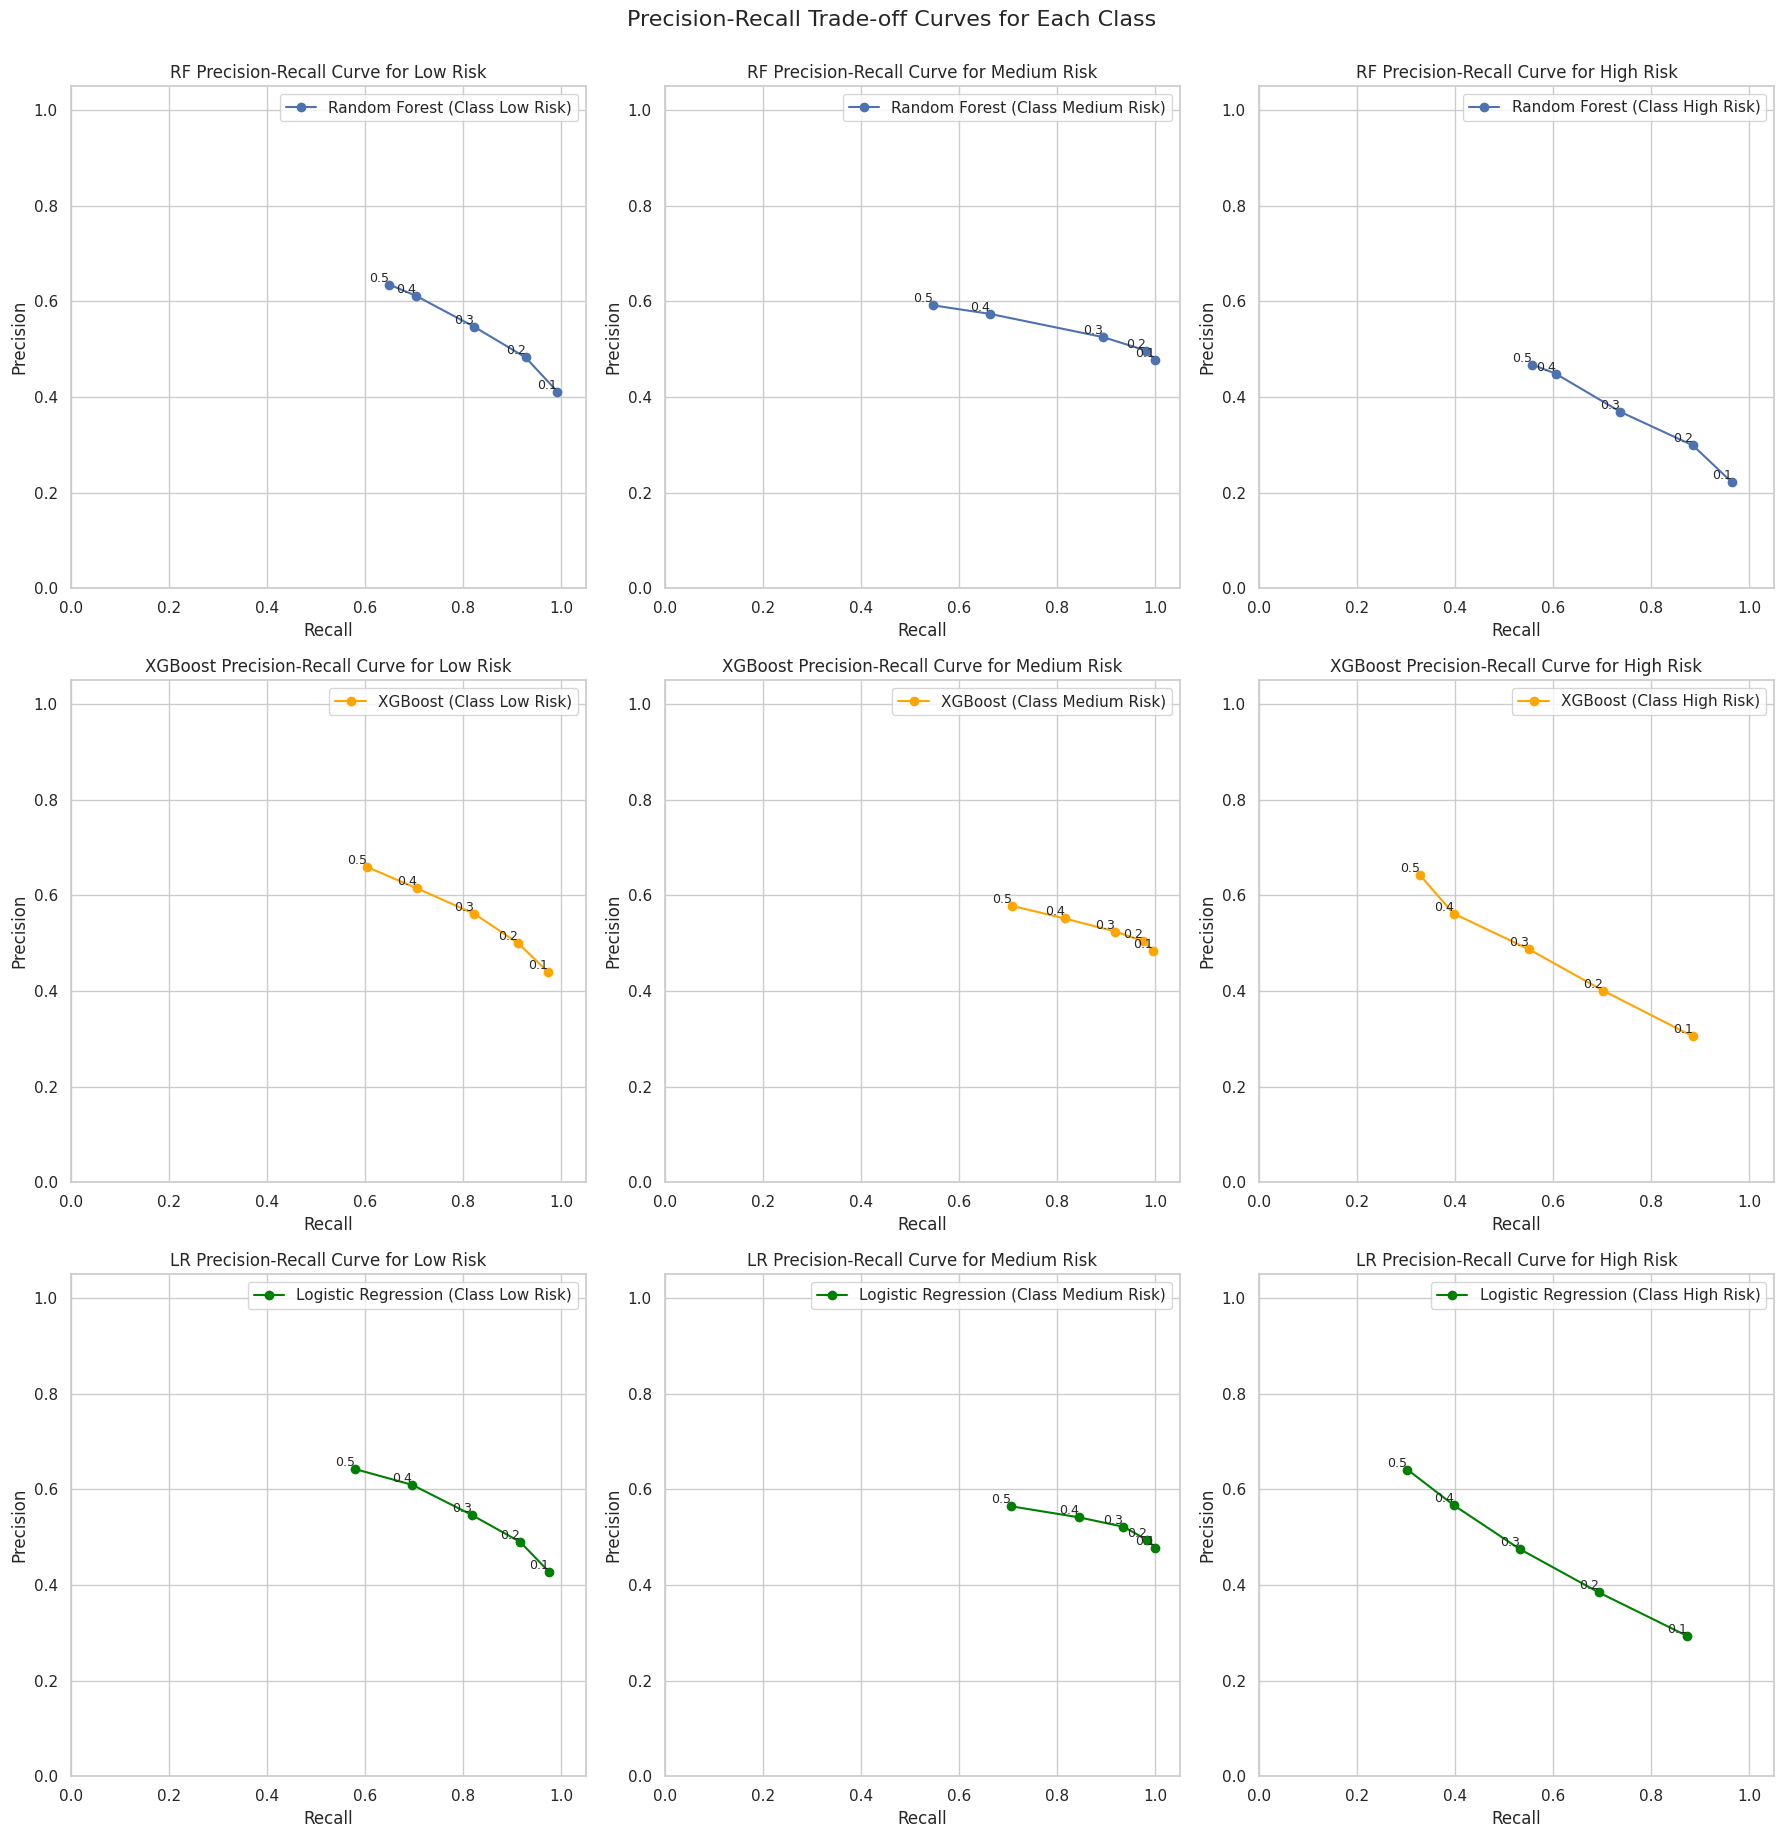

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Precision-Recall Curves

plt.figure(figsize=(18, 18)) # Increased figure height to accommodate 3 rows

for i, class_label in enumerate(risk_labels):
    # Random Forest Plot
    plt.subplot(3, 3, i + 1) # Changed to 3 rows
    plt.plot(rf_pr_curves[i]['recall'], rf_pr_curves[i]['precision'], marker='o', linestyle='-', label=f'Random Forest (Class {class_label})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'RF Precision-Recall Curve for {class_label}')
    plt.legend()
    plt.grid(True)
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.05])
    # Add threshold values
    for j in range(len(rf_pr_curves[i]['threshold'])):
        plt.text(rf_pr_curves[i]['recall'][j], rf_pr_curves[i]['precision'][j], f'{rf_pr_curves[i]['threshold'][j]:.1f}', fontsize=9, ha='right', va='bottom')

    # XGBoost Plot
    plt.subplot(3, 3, i + 4) # Adjusted subplot index for the second row
    plt.plot(xgb_pr_curves[i]['recall'], xgb_pr_curves[i]['precision'], marker='o', linestyle='-', color='orange', label=f'XGBoost (Class {class_label})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'XGBoost Precision-Recall Curve for {class_label}')
    plt.legend()
    plt.grid(True)
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.05])
    # Add threshold values
    for j in range(len(xgb_pr_curves[i]['threshold'])):
        plt.text(xgb_pr_curves[i]['recall'][j], xgb_pr_curves[i]['precision'][j], f'{xgb_pr_curves[i]['threshold'][j]:.1f}', fontsize=9, ha='right', va='bottom')

    # Logistic Regression Plot - NEW
    plt.subplot(3, 3, i + 7) # Adjusted subplot index for the third row
    plt.plot(lr_pr_curves[i]['recall'], lr_pr_curves[i]['precision'], marker='o', linestyle='-', color='green', label=f'Logistic Regression (Class {class_label})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'LR Precision-Recall Curve for {class_label}')
    plt.legend()
    plt.grid(True)
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.05])
    # Add threshold values
    for j in range(len(lr_pr_curves[i]['threshold'])):
        plt.text(lr_pr_curves[i]['recall'][j], lr_pr_curves[i]['precision'][j], f'{lr_pr_curves[i]['threshold'][j]:.1f}', fontsize=9, ha='right', va='bottom')

plt.tight_layout()
plt.suptitle('Precision-Recall Trade-off Curves for Each Class', y=1.02, fontsize=16)
plt.show()

### Save Best Models

In [ ]:
import joblib

# Save the best Random Forest model
rf_model_filename = '../saved_models/random_forest_model_pipeline.joblib'
joblib.dump(best_rf_model, rf_model_filename)
print(f"Trained Random Forest model pipeline saved to '{rf_model_filename}'")

# Save the best XGBoost model
xgb_model_filename = '../saved_models/xgboost_model_pipeline.joblib'
joblib.dump(best_random_xgb_model, xgb_model_filename)
print(f"Trained XGBoost model pipeline saved to '{xgb_model_filename}'")

# Save the best LogisticRegression Model

lr_model_filename = '../saved_models/logistic_regression_model_pipeline.joblib'
joblib.dump(best_lr_model, lr_model_filename)
print(f"Trained Logistic Regression model pipeline saved to '{lr_model_filename}'")

Trained Random Forest model pipeline saved to 'random_forest_model_pipeline.joblib'
Trained XGBoost model pipeline saved to 'xgboost_model_pipeline.joblib'
Trained Logistic Regression model pipeline saved to 'logistic_regression_model_pipeline.joblib'


## Feature Importance Comparison

Random Forest Feature Importances:
 num__total_distress_score              0.16
log__work_to_sleep_ratio               0.15
log__active_vs_screen_ratio            0.11
num__situational_stress_load           0.09
num__protective_buffer_score           0.09
num__clinical_vulnerability_index      0.07
num__mood_swings_frequency             0.07
num__concentration_difficulty_level    0.07
cat__gender_Other                      0.02
cat__marital_status_Married            0.02
cat__gender_Male                       0.02
cat__marital_status_Single             0.02
cat__employment_status_Self-Employed   0.02
cat__employment_status_Student         0.02
cat__employment_status_Unemployed      0.02
cat__education_level_High School       0.02
cat__age_group_Senior                  0.01
cat__education_level_Master            0.01
cat__education_level_PhD               0.01
cat__age_group_Young_Adult             0.01
cat__age_group_Youth                   0.01
dtype: float64


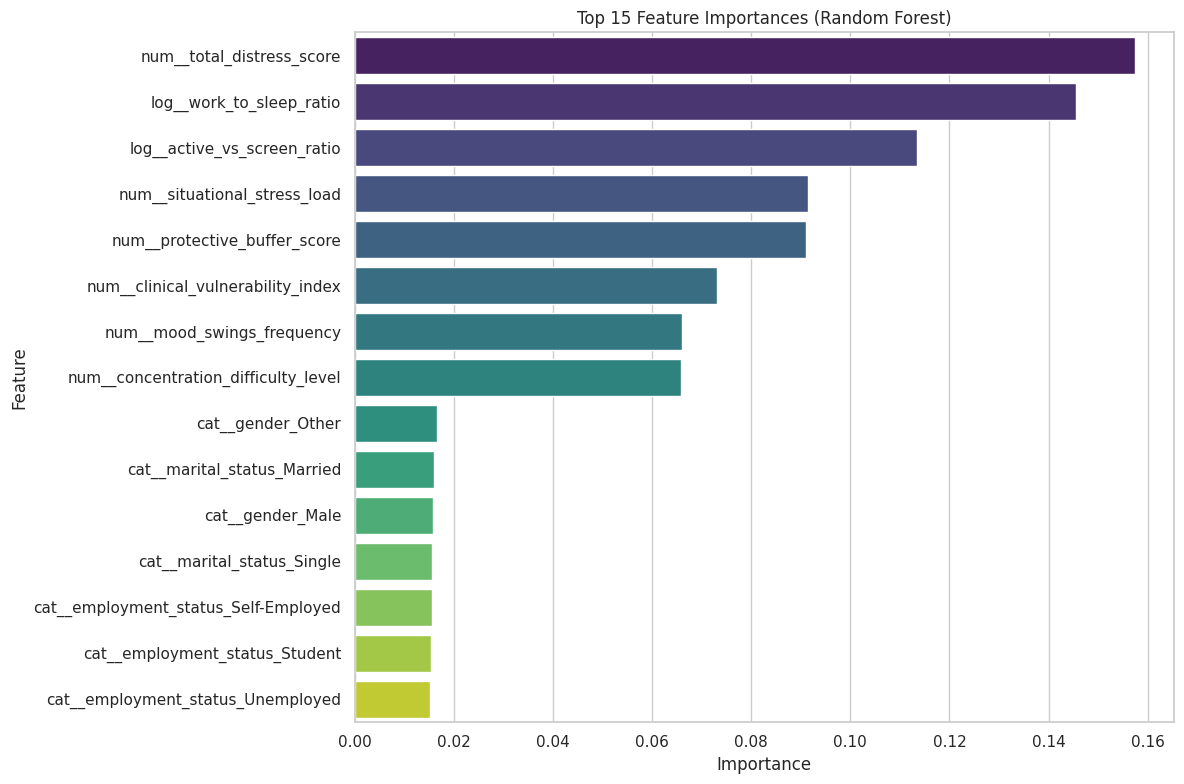

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names after preprocessing
# The column_transformer is the 'preprocessor' step in the rf_pipeline
feature_names_out = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances from Random Forest
rf_feature_importances = pd.Series(rf_pipeline.named_steps['model'].feature_importances_, index=feature_names_out)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)

print("Random Forest Feature Importances:\n", rf_feature_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x=rf_feature_importances.head(15).values, y=rf_feature_importances.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

XGBoost Feature Importances:
 num__total_distress_score              0.22
num__clinical_vulnerability_index      0.15
log__work_to_sleep_ratio               0.08
num__protective_buffer_score           0.07
num__situational_stress_load           0.06
log__active_vs_screen_ratio            0.04
cat__gender_Male                       0.03
cat__age_group_Youth                   0.03
cat__education_level_PhD               0.03
cat__employment_status_Student         0.03
cat__age_group_Young_Adult             0.03
cat__gender_Other                      0.03
cat__education_level_High School       0.03
cat__marital_status_Single             0.03
num__concentration_difficulty_level    0.03
num__mood_swings_frequency             0.02
cat__employment_status_Self-Employed   0.02
cat__employment_status_Unemployed      0.02
cat__education_level_Master            0.02
cat__marital_status_Married            0.02
cat__age_group_Senior                  0.02
dtype: float32


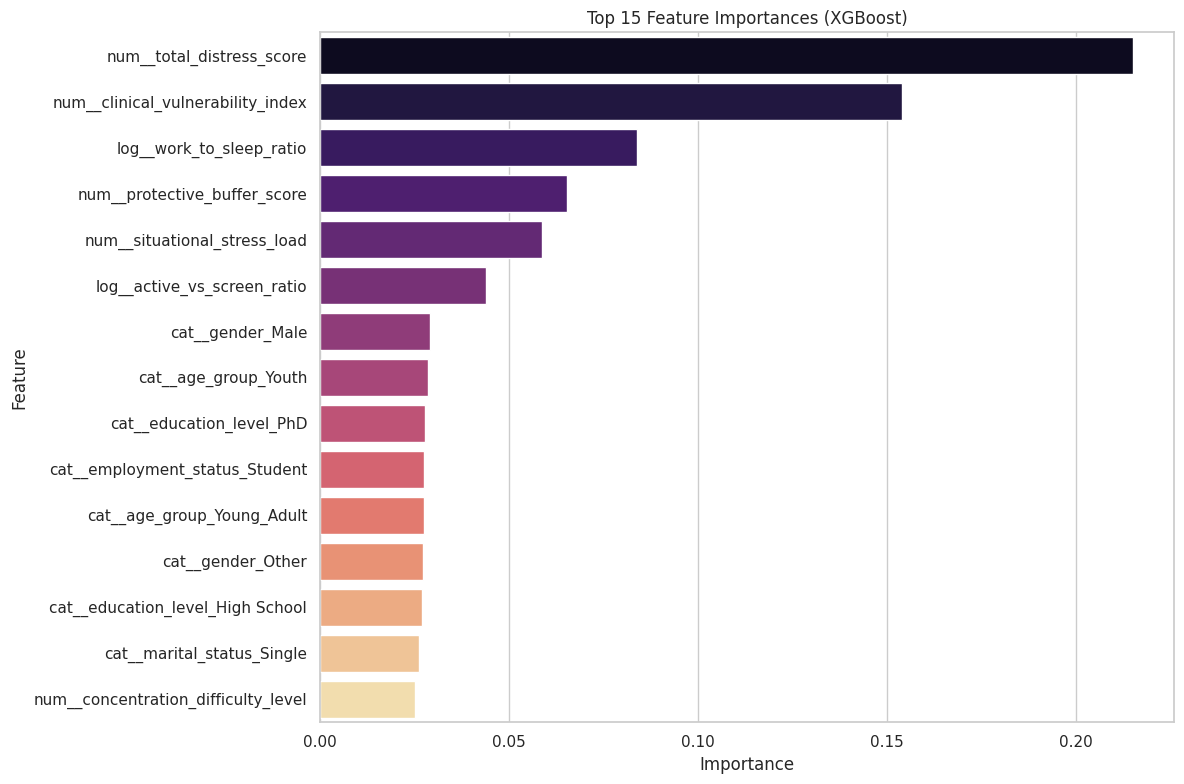

In [48]:
# Get feature importances from XGBoost
feature_names_out_xgb = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
xgb_feature_importances = pd.Series(xgb_pipeline.named_steps['model'].feature_importances_, index=feature_names_out_xgb)

xgb_feature_importances = xgb_feature_importances.sort_values(ascending=False)

print("XGBoost Feature Importances:\n", xgb_feature_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_feature_importances.head(15).values, y=xgb_feature_importances.head(15).index, palette='magma')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Logistic Regression Feature Importances:
 log__active_vs_screen_ratio             1.26
num__protective_buffer_score            0.30
cat__age_group_Senior                   0.04
cat__age_group_Youth                    0.04
cat__marital_status_Married             0.02
cat__gender_Male                        0.02
cat__gender_Other                       0.01
num__concentration_difficulty_level     0.01
num__mood_swings_frequency             -0.01
cat__education_level_High School       -0.01
cat__employment_status_Student         -0.04
cat__employment_status_Self-Employed   -0.04
cat__age_group_Young_Adult             -0.04
cat__employment_status_Unemployed      -0.05
cat__education_level_Master            -0.06
cat__marital_status_Single             -0.06
cat__education_level_PhD               -0.09
num__situational_stress_load           -0.28
num__clinical_vulnerability_index      -0.62
num__total_distress_score              -0.79
log__work_to_sleep_ratio               -2.03
dtype: float6

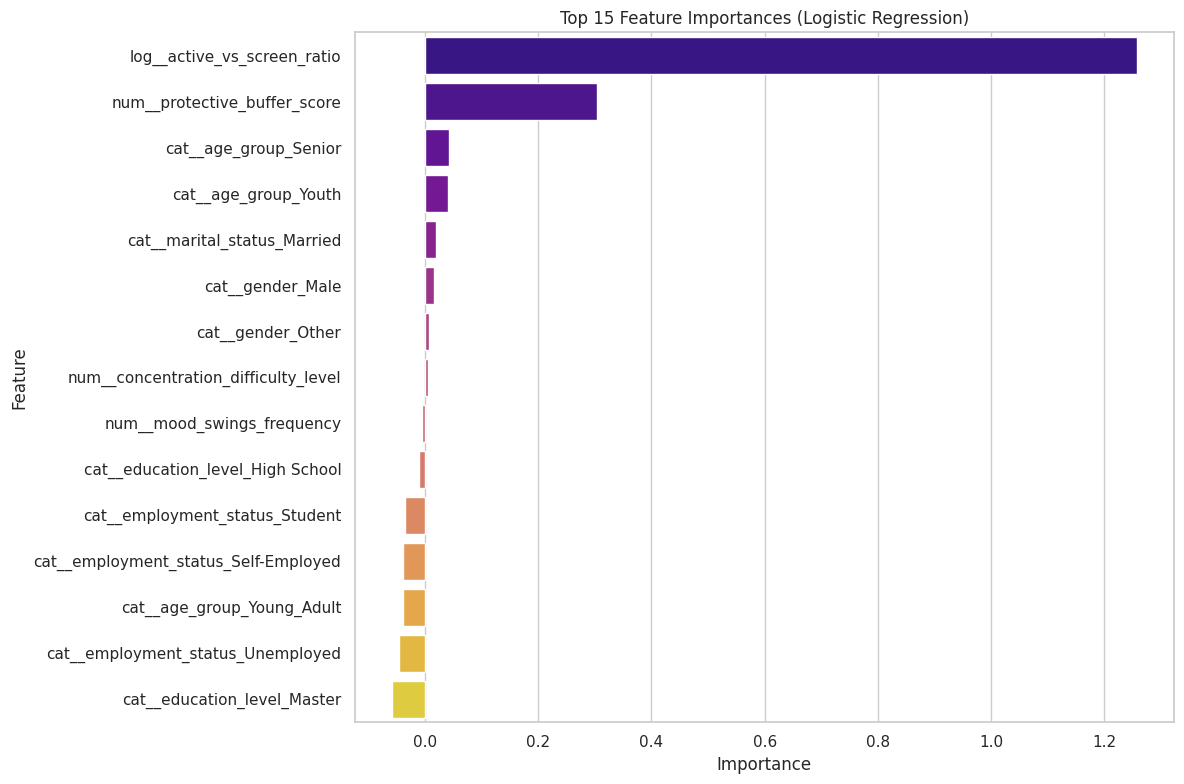

In [49]:
# Get feature importance for LogisticRegression
# lr_feature_importances = pd.Series(best_lr_model.named_steps['model'].coef_[0], index=feature_names_out)
lr_feature_importances = pipeline.named_steps['preprocessor'].get_feature_names_out()
lr_feature_importances = pd.Series(best_lr_model.named_steps['model'].coef_[0], index=lr_feature_importances)
lr_feature_importances = lr_feature_importances.sort_values(ascending=False)

print("Logistic Regression Feature Importances:\n", lr_feature_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x=lr_feature_importances.head(15).values, y=lr_feature_importances.head(15).index, palette='plasma')
plt.title('Top 15 Feature Importances (Logistic Regression)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Side by Side feature importance comparison of LogisticRegression/RandomForest/Xgboost

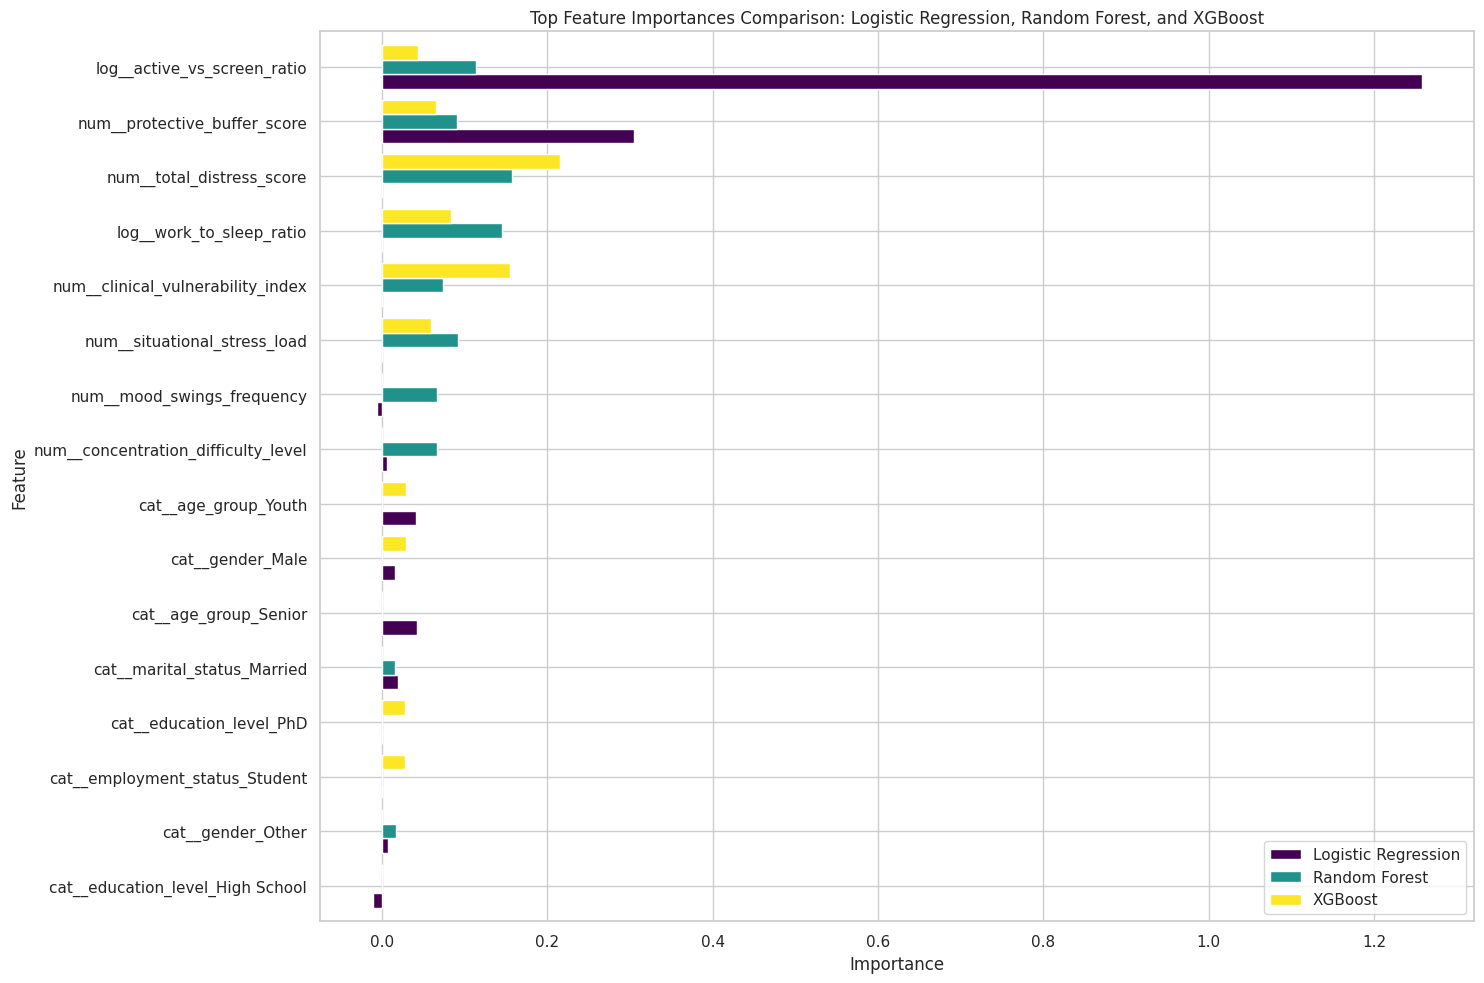

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 features from each model
top_rf_features = rf_feature_importances.head(10)
top_xgb_features = xgb_feature_importances.head(10)
top_lr_features = lr_feature_importances.head(10) # Correctly get LR top features

# Combine them into a single DataFrame for plotting
combined_features = pd.DataFrame({
    'Logistic Regression': top_lr_features, # Corrected assignment
    'Random Forest': top_rf_features,
    'XGBoost': top_xgb_features
}).fillna(0) # Fill NaN with 0 if a feature is not in both top lists

# Sort by overall importance for better visualization
combined_features['Overall_Importance'] = combined_features.abs().sum(axis=1) # Use absolute sum for sorting
combined_features = combined_features.sort_values(by='Overall_Importance', ascending=True).drop(columns='Overall_Importance') # Sort ascending to have highest at top in barh

# Plotting
fig, ax = plt.subplots(figsize=(15, 10))
combined_features.plot(kind='barh', ax=ax, width=0.8, cmap='viridis')
ax.set_title('Top Feature Importances Comparison: Logistic Regression, Random Forest, and XGBoost') # Corrected title
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
# ax.invert_yaxis() # Not needed if sorting ascending and using barh
plt.tight_layout()
plt.show()

## Misclassification Analysis

# MIS-CLASSIFICATION comparison of Three tuned models

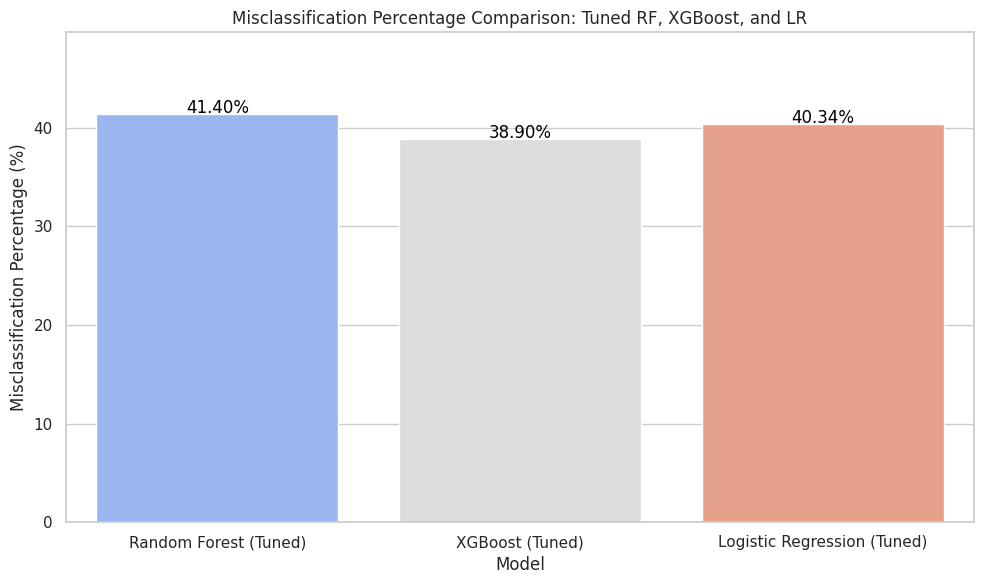

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for Logistic Regression
y_pred_lr = best_lr_model.predict(X_test)

# Identify misclassified samples for Logistic Regression
misclassified_lr_indices = X_test.index[y_pred_lr != y_test]
misclassified_lr_count = len(misclassified_lr_indices)

# Get predictions for Random Forest (tuned model)
y_pred_rf_tuned = best_rf_model.predict(X_test)
misclassified_rf_tuned_indices = X_test.index[y_pred_rf_tuned != y_test]
misclassified_rf_tuned_count = len(misclassified_rf_tuned_indices)

# Get predictions for XGBoost (tuned model)
y_pred_xgb_tuned = best_random_xgb_model.predict(X_test)
misclassified_xgb_tuned_indices = X_test.index[y_pred_xgb_tuned != y_test]
misclassified_xgb_tuned_count = len(misclassified_xgb_tuned_indices)

# Total number of samples in the test set
total_test_samples = len(y_test)

# Calculate misclassification percentages
misclassification_rf_percent = (misclassified_rf_tuned_count / total_test_samples) * 100
misclassification_xgb_percent = (misclassified_xgb_tuned_count / total_test_samples) * 100
misclassification_lr_percent = (misclassified_lr_count / total_test_samples) * 100

# Create a DataFrame for plotting
misclassification_data = pd.DataFrame({
    'Model': ['Random Forest (Tuned)', 'XGBoost (Tuned)', 'Logistic Regression (Tuned)'],
    'Misclassification %': [misclassification_rf_percent, misclassification_xgb_percent, misclassification_lr_percent]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Misclassification %', data=misclassification_data, palette='coolwarm')
plt.title('Misclassification Percentage Comparison: Tuned RF, XGBoost, and LR')
plt.xlabel('Model')
plt.ylabel('Misclassification Percentage (%)')
plt.ylim(0, max(misclassification_rf_percent, misclassification_xgb_percent, misclassification_lr_percent) * 1.2)

# Add text labels on top of the bars
for index, row in misclassification_data.iterrows():
    plt.text(row.name, row['Misclassification %'] + 0.1, f"{row['Misclassification %']:.2f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

I can load the model back into memory later using:
```python
# loaded_model = joblib.load(model_filename)
# print(f"Model loaded from {model_filename}")
```

# Plot ROC-AUC curves for all three tuned models in one figure

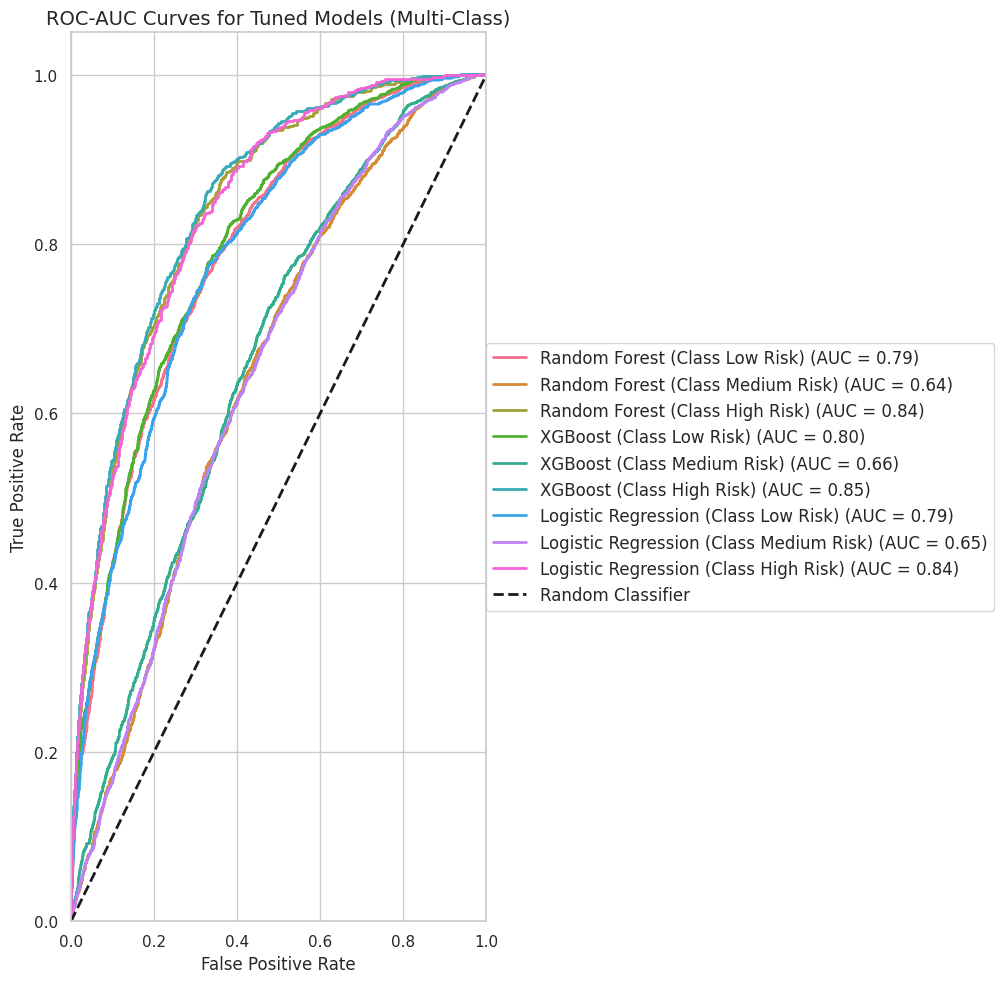

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

plt.figure(figsize=(12, 10)) # Slightly larger figure for better readability
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk'] # Ensure risk_labels are defined
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

models_to_plot = {
    'Random Forest': best_rf_model,
    'XGBoost': best_random_xgb_model,
    'Logistic Regression': best_lr_model
}

# Define a palette with enough distinct colors for all 3 models * 3 classes = 9 lines
colors = sns.color_palette("husl", n_colors=len(models_to_plot) * n_classes)
color_idx = 0

for model_name, model_pipeline in models_to_plot.items():
    y_prob = model_pipeline.predict_proba(X_test)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        roc_auc_val = auc(fpr, tpr)
        # Plot each curve with a unique color and a solid line
        plt.plot(fpr, tpr, color=colors[color_idx], lw=2,
                 label=f'{model_name} (Class {risk_labels[i]}) (AUC = {roc_auc_val:.2f})')
        color_idx += 1

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier') # Add label for random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for Tuned Models (Multi-Class)', fontsize=14)
# Adjust legend placement to outside the plot area to prevent overlap
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='medium', borderaxespad=0.)
plt.grid(True)
# Adjust layout to make space for the legend when saving/showing the plot
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

From the plot, we  can observe:

* All three models show good discrimination ability for the 'High Risk' class (Class 2), with AUC values around 0.84 to 0.85.
* The performance for the 'Low Risk' class (Class 0) is also relatively strong, with AUC values ranging from 0.79 (RF and LR) to 0.80 (XGBoost).
* The 'Medium Risk' class (Class 1) is the most challenging for all models, showing lower AUC values, ranging from 0.64 (RF) to 0.66 (XGBoost).
* XGBoost appears to have a slight edge in distinguishing the 'Medium Risk' class and overall, as previously noted by its slightly higher average ROC AUC score (0.76) compared to Logistic Regression (0.75) and Random Forest (0.75).

Overall ovservation

* In terms of performance XGBoost doing better job compared to RandomForest & LogisticRegresion.
* In terms of misclassification rate XGboost has lowest misclasification
* Comparing precision-recall scores across all THREE classes at different threshold show both LogisticRegression/XGBoost doing better job  
* Feature importance comparison shows XGboost uses more input features compared to other 2 algorithms. This indicates XGboost trying to explore more features to identify the variances. This approach is better compared to putting more focus on   only few feature like LogisticRegression uses protective_buffer_score and active_screen_ration predominantly.
XGboost even uses few catetogrical features that no other algorithms considers.

# **Overall Verdict**

Following Algorithms are evaluated

- LogisticRegression(Base Model)
- XGBoost
- RandomForest
- Neural Network - (Separate notebook used--> analysis_with_feature_engg_NeuralNetwork.ipynb)


1. Based on the above analysis and results for this UseCase

Considering the following factors

        a. Overall performance (train/test time)

        b. Metrics (Recall, F1-score, Precision, Confusion Metrix, ROC-AUC)

        c. Robustness in feature selection/utilization

        d. Misclassification rate

        e. Consistent precision/Recall balance across different THRESHOLDs


My vote

        I. Choice 1 - XGBoost **(Can be productionized )**

        II. Choice 2 - LogisticRegression (Can be used as baseline model for further analysis )
            
2. To improve model's Recall score for high_risk/low_risk keep threshold between 0.3 to 0.4.

# **Next step**

**Actionable Items :**

    1. Analyse which other Clinical Assessment, Diagnostic Criteria, Identifying Triggers can be used as additional input features to identify mental risk factors accurately.
    2. Talk to healthcare domain expert & get more insights on clinical data.This will help in generating synthetic data with proper distribution. My data generation technique didn't produce good reliable data for testing.
    3. Discuss with domain experts/ healthcare providers to see how/from where I can get real data
    4. When I get access to real data stratetize how to  handle tokenized PI/SPI data elements, as appropriate.  
    5. Additional Feature Engineering Techniques, if needed based on domain experts'feedback,  to Enhance Class Separation
    6. Interaction Features


# **END OF CAPSTONE PROJECT**